# Bank IRRBB & Liquidity Report

**Report Date:** 2024-12-31  
**Currency:** PLN (primary)  
**Purpose:** Executive overview — balance sheet, interest rate risk, liquidity and behavioural model outputs.

---
| # | Section |
|---|---|
| 1 | Balance Sheet Summary |
| 2 | Market Yield Curves |
| 2b | IRRBB Scenario Yield Curves (base + 6 EBA shocks) |
| 3 | Interest Rate Repricing Gap |
| 4 | Liquidity Gap |
| 5 | Behavioural Run-off |
| 6 | Simple NII Sensitivity ±100 bps |
| 7 | EBA IRRBB SOT — ΔEVE & ΔNII |
| 8 | LCR & NSFR |
| 9 | Additional ALM Insights |
| 10 | Non-linearity Analysis (NII & EVE) |


In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
from sqlalchemy import create_engine, text

ENGINE = create_engine(
    'mssql+pyodbc://maciek_d/bank_gen'
    '?driver=ODBC+Driver+17+for+SQL+Server'
    '&Trusted_Connection=yes',
    future=True,
)
REPORT_DATE = pd.to_datetime('2024-12-31')
CCY = 'PLN'

# ── Plotting style ──────────────────────────────────────────────────────────
plt.rcParams.update({
    'figure.dpi': 100,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.35,
    'grid.linestyle': '--',
    'font.size': 9,
    'axes.titlesize': 11,
    'axes.titleweight': 'bold',
    'axes.titlepad': 8,
    'legend.fontsize': 8,
    'legend.framealpha': 0.8,
})

# ── Color palette ────────────────────────────────────────────────────────────
C_A  = '#1565C0'   # asset / positive
C_L  = '#C62828'   # liability / negative
C_N  = '#2E7D32'   # net
C_EQ = '#6A1B9A'   # equity
C_UP = '#D32F2F'   # rate-up shock
C_DN = '#1565C0'   # rate-down shock
C_OK = '#2E7D32'   # compliant
C_WN = '#E65100'   # warning
C_GR = '#455A64'   # grey / neutral

BLUES  = ['#1565C0', '#1976D2', '#42A5F5', '#90CAF9', '#BBDEFB']
REDS   = ['#C62828', '#D32F2F', '#EF5350', '#EF9A9A', '#FFCDD2']

# ── Helpers ──────────────────────────────────────────────────────────────────
def rsql(q, **p):
    return pd.read_sql_query(text(q), ENGINE, params=p)

def tkey(lbl):
    """Sort key for tenor bucket labels."""
    if lbl == '1D': return 0
    if lbl == '>30Y': return 999_999
    if lbl.endswith('Y'): return int(lbl[:-1]) * 12
    if lbl.endswith('M'): return int(lbl[:-1])
    return 99_999

def sbkt(df, col='tenor_bucket'):
    return df.assign(_s=df[col].map(tkey)).sort_values('_s').drop(columns='_s')

def pct_fmt(v, _=None): return f'{v:.0f}%'
def bn_fmt(v, _=None):  return f'{v:.1f}B'
def mn_fmt(v, _=None):  return f'{v:.0f}M'

print(f'Setup complete  |  Report date: {REPORT_DATE.date()}')

Setup complete  |  Report date: 2024-12-31


## Data Loading

In [2]:
RD = REPORT_DATE

# 1. Balance sheet
bs_raw = rsql('''
    SELECT product_name, bs_side, currency, SUM(balance_amt) AS balance_amt
    FROM dbo.transactions
    WHERE report_date = :rd
    GROUP BY product_name, bs_side, currency
''', rd=RD)

equity_amt = float(rsql(
    'SELECT ISNULL(SUM(balance_amt),0) AS v FROM schemat.equity WHERE report_date=:rd',
    rd=RD)['v'].iloc[0])

loan_rt = rsql('''
    SELECT ISNULL(rate_type,'V') AS rate_type, currency, SUM(balance_amt) AS balance_amt
    FROM schemat.loans WHERE bs_side='A' AND report_date=:rd
    GROUP BY rate_type, currency
''', rd=RD)

dep_rt = rsql('''
    SELECT ISNULL(rate_type,'V') AS rate_type, currency, SUM(balance_amt) AS balance_amt
    FROM schemat.deposits WHERE bs_side='L' AND report_date=:rd
    GROUP BY rate_type, currency
''', rd=RD)

# 2. Market yield curves
mkt = rsql('''
    SELECT curve_name, n_days, zero_rate, d_f
    FROM mkt.curves WHERE curve_date=:rd
    ORDER BY curve_name, n_days
''', rd=RD)

# 3. IR repricing gap
try:
    ir_gap = rsql('''
        SELECT currency, bs_side, tenor_bucket,
               bucket_start_dt, bucket_end_dt, cf_end_dt,
               gap_cf,
               ISNULL(gap_cf_ca, 0)  AS gap_cf_ca,
               ISNULL(gap_cf_irs, 0) AS gap_cf_irs
        FROM irrbb.ir_gap_beh
    ''')
except Exception:
    ir_gap = rsql('''
        SELECT currency, bs_side, tenor_bucket,
               bucket_start_dt, bucket_end_dt, cf_end_dt,
               gap_cf, 0.0 AS gap_cf_ca, 0.0 AS gap_cf_irs
        FROM irrbb.ir_gap_beh
    ''')
    print('  ir_gap loaded without IRS/CA columns')

# 4. Liquidity gap
liq_gap = rsql('''
    SELECT currency, bs_side, tenor_bucket,
           bucket_start_dt, bucket_end_dt, cf_end_dt, gap_cf
    FROM irrbb.liq_gap_beh
''')

# 5. Behavioural run-off
# product_code → product_name lookup from dbo.transactions
product_code_map = rsql('''
    SELECT DISTINCT product_code, product_name, bs_side
    FROM dbo.transactions
    WHERE report_date = :rd
''', rd=RD)

runoff = rsql('''
    SELECT product_type, product_code, bs_side, currency, cf_end_dt,
           SUM(ISNULL(beh_capital_pmt,0) + ISNULL(prepayment_pmt,0)) AS beh_cap,
           SUM(ISNULL(con_capital_pmt,0))                             AS con_cap
    FROM cf.products
    WHERE cf_end_dt > :rd AND COALESCE(beh_total_pmt,0) <> 0
    GROUP BY product_type, product_code, bs_side, currency, cf_end_dt
''', rd=RD)
runoff['cf_end_dt'] = pd.to_datetime(runoff['cf_end_dt'])
# enrich with product_name from lookup
runoff = runoff.merge(
    product_code_map[['product_code', 'product_name']].drop_duplicates('product_code'),
    on='product_code', how='left')

# Outstanding balances per product for run-off notional display
outstanding_bal = rsql('''
    SELECT product_code, product_name, bs_side, currency,
           SUM(balance_amt) AS balance_amt
    FROM dbo.transactions
    WHERE report_date = :rd
    GROUP BY product_code, product_name, bs_side, currency
''', rd=RD)

# IRS book: use gap_cf_irs from ir_gap (already loaded)
irs_book = (ir_gap[ir_gap['gap_cf_irs'] != 0]
            .groupby(['currency', 'tenor_bucket'])[['gap_cf', 'gap_cf_irs']]
            .sum().reset_index())

# 6. NII & EVE per scenario
nii_scen = rsql('''
    SELECT scenario_id, currency,
           SUM(nii_interest) AS nii_interest,
           SUM(nii_renewal)  AS nii_renewal,
           SUM(nii_total)    AS nii_total
    FROM irrbb.nii_results WHERE report_date=:rd
    GROUP BY scenario_id, currency
''', rd=RD)

eve_scen = rsql('''
    SELECT scenario_id, currency,
           SUM(pv_capital)  AS pv_capital,
           SUM(pv_interest) AS pv_interest,
           SUM(pv_total)    AS pv_total
    FROM irrbb.eve_results WHERE report_date=:rd
    GROUP BY scenario_id, currency
''', rd=RD)

# 7. IRRBB SOT
try:
    irrbb_sot = rsql('''
        SELECT scenario_id, currency,
               delta_nii, sot_nii_pct, delta_nii_reg, sot_nii_pct_reg,
               delta_eve, sot_eve_pct, delta_eve_reg, sot_eve_pct_reg
        FROM irrbb.irrbb_report WHERE report_date=:rd
    ''', rd=RD)
except Exception as e:
    irrbb_sot = pd.DataFrame()
    print(f'  SOT not available: {e}')

tier1 = float(rsql(
    'SELECT ISNULL(SUM(balance_amt),0) AS v FROM schemat.equity WHERE report_date=:rd',
    rd=RD)['v'].iloc[0])

# 8. LCR / NSFR
try:
    lcr_nsfr = rsql('''
        SELECT currency, hqla, outflows_30d, inflows_30d,
               net_outflows_30d, lcr, asf, rsf, nsfr
        FROM results.lcr_nsfr WHERE report_date=:rd
    ''', rd=RD)
except Exception as e:
    lcr_nsfr = pd.DataFrame()
    print(f'  LCR/NSFR not available: {e}')

print('Data loaded:')
print(f'  Balance sheet rows : {len(bs_raw):,}')
print(f'  IR gap buckets     : {ir_gap["tenor_bucket"].nunique()}')
print(f'  Liq gap buckets    : {liq_gap["tenor_bucket"].nunique()}')
print(f'  NII scenarios      : {nii_scen["scenario_id"].nunique()}')
print(f'  EVE scenarios      : {eve_scen["scenario_id"].nunique()}')
print(f'  Tier 1 capital     : {tier1/1e9:.2f} B PLN')
# 9. IRRBB shocked curves (for scenario curve plot)
try:
    irrbb_curves = rsql('''
        SELECT scenario_id, curve_name, n_days, d_f, zero_rt
        FROM irrbb.curves
        WHERE report_date = :rd
          AND curve_name = 'PLN_disc_curve'
          AND scenario_id IN ('base','par_up','par_dn','steep','flat','sr_up','sr_dn')
        ORDER BY scenario_id, n_days
    ''', rd=RD)
except Exception as e:
    irrbb_curves = pd.DataFrame()
    print(f'  IRRBB curves not available: {e}')

# 10. NII own scenarios (own_1_up/dn, own_100_up/dn) for non-linearity
try:
    nii_own = rsql('''
        SELECT scenario_id, currency, SUM(nii_total) AS nii_total
        FROM cf.nii_own_scenarios
        WHERE report_date = :rd
        GROUP BY scenario_id, currency
    ''', rd=RD)
except Exception as e:
    nii_own = pd.DataFrame()
    print(f'  NII own scenarios not available: {e}')

# 10b. NII base scenario CF table (consistent base for 1bps delta)
try:
    nii_cf_base = rsql('''
        SELECT scenario_id, currency, SUM(nii_total) AS nii_total
        FROM cf.nii_base_scenario
        WHERE report_date = :rd
        GROUP BY scenario_id, currency
    ''', rd=RD)
except Exception as e:
    nii_cf_base = pd.DataFrame()
    print(f'  NII base CF scenario not available: {e}')

# 11. EVE own scenarios (own_1_up/dn, own_100_up/dn) for non-linearity
try:
    eve_own = rsql('''
        SELECT scenario_id, currency,
               SUM(pv_capital) + SUM(pv_interest) AS pv_total
        FROM cf.eve_own_scenarios
        WHERE report_date = :rd
          AND scenario_id <> 'base'
        GROUP BY scenario_id, currency
    ''', rd=RD)
except Exception as e:
    eve_own = pd.DataFrame()
    print(f'  EVE own scenarios not available: {e}')


Data loaded:
  Balance sheet rows : 17
  IR gap buckets     : 85
  Liq gap buckets    : 114
  NII scenarios      : 8
  EVE scenarios      : 8
  Tier 1 capital     : 1.20 B PLN


---
## 0. Key Metrics Dashboard

In [3]:
# ─────────────────────────────────────────────────────────────────────────────
# KEY METRICS DASHBOARD  — executive snapshot
# ─────────────────────────────────────────────────────────────────────────────
pln_a = bs_raw[(bs_raw['currency'] == CCY) & (bs_raw['bs_side'] == 'A')]['balance_amt'].sum()
pln_l = bs_raw[(bs_raw['currency'] == CCY) & (bs_raw['bs_side'] == 'L')]['balance_amt'].sum()

nii_base = float(nii_scen[(nii_scen['currency'] == CCY) &
                           (nii_scen['scenario_id'] == 'base')]['nii_total'].sum())
eve_base = float(eve_scen[(eve_scen['currency'] == CCY) &
                           (eve_scen['scenario_id'] == 'base')]['pv_total'].sum())

# 1bps NII sensitivity from own scenarios
def _get_1bp(df, sid, col):
    if df.empty: return None
    sub = df[(df['currency'] == CCY) & (df['scenario_id'] == sid)]
    return float(sub[col].sum()) if not sub.empty else None

_n1up_abs  = _get_1bp(nii_own,     'own_1_up', 'nii_total')
_n1dn_abs  = _get_1bp(nii_own,     'own_1_dn', 'nii_total')
_n1base    = _get_1bp(nii_cf_base,  'base',     'nii_total')
# Use cf.nii_base_scenario as base: same write_shocked_cf_products pipeline
# as own scenarios -> consistent delta (irrbb.nii_results uses a different path)
_cf_base   = _n1base if _n1base is not None else nii_base
dnii_1up   = (_n1up_abs - _cf_base) if _n1up_abs is not None else None
dnii_1dn   = (_n1dn_abs - _cf_base) if _n1dn_abs is not None else None

g_1y = ir_gap[(ir_gap['currency'] == CCY) &
              (ir_gap['tenor_bucket'].map(tkey) <= 12)]['gap_cf'].sum()
dnii_up100 = g_1y * 0.01 * 0.5   # approx: avg 6M remaining in 12M horizon

lcr_v  = float(lcr_nsfr['lcr'].mean()) * 100 \
          if not lcr_nsfr.empty and 'lcr' in lcr_nsfr.columns else None
nsfr_v = float((lcr_nsfr['asf'] / lcr_nsfr['rsf'].replace(0, float('nan'))).mean()) * 100 \
          if not lcr_nsfr.empty and 'asf' in lcr_nsfr.columns else None

worst_eve_pct = None
if not irrbb_sot.empty and 'sot_eve_pct_reg' in irrbb_sot.columns:
    worst_eve_pct = float(irrbb_sot[irrbb_sot['currency'] == CCY]['sot_eve_pct_reg'].min())

worst_nii_pct = None
if not irrbb_sot.empty and 'sot_nii_pct_reg' in irrbb_sot.columns:
    worst_nii_pct = float(irrbb_sot[irrbb_sot['currency'] == CCY]['sot_nii_pct_reg'].min())

SEP  = '=' * 58
SEP2 = '-' * 58
print(f'\n{SEP}')
print(f'  KEY METRICS  |  {CCY}  |  {REPORT_DATE.date()}')
print(f'{SEP}')
print(f'  BALANCE SHEET')
print(f'    Total assets         {pln_a / 1e9:>10.2f}  B PLN')
print(f'    Total liabilities    {pln_l / 1e9:>10.2f}  B PLN')
print(f'    Tier 1 capital       {tier1  / 1e9:>10.2f}  B PLN')
print(f'{SEP2}')
print(f'  INCOME & VALUE')
print(f'    Base NII             {nii_base / 1e6:>+10.1f}  M PLN')
print(f'    Base EVE             {eve_base / 1e6:>+10.1f}  M PLN')
if dnii_1up is not None:
    print(f'    DNII +1bps           {dnii_1up / 1e6:>+10.3f}  M PLN')
if dnii_1dn is not None:
    print(f'    DNII -1bps           {dnii_1dn / 1e6:>+10.3f}  M PLN')
print(f'{SEP2}')
print(f'  INTEREST RATE RISK')
print(f'    IR gap <=12M         {g_1y / 1e6:>+10.1f}  M PLN  ' +
      f'({"asset-sensitive" if g_1y >= 0 else "liability-sensitive"})')
print(f'    Simple DNII +100bp   {dnii_up100 / 1e6:>+10.1f}  M PLN  (approx, avg remain_yf=0.5)')
if worst_eve_pct is not None:
    flag = '  *** BREACH' if worst_eve_pct < -15 else '  ok'
    print(f'    Worst DEVE/T1 (reg)  {worst_eve_pct:>+10.1f}  %    (threshold -15%){flag}')
if worst_nii_pct is not None:
    flag = '  *** BREACH' if worst_nii_pct < -5 else '  ok'
    print(f'    Worst DNII/T1 (reg)  {worst_nii_pct:>+10.1f}  %    (threshold  -5%){flag}')
print(f'{SEP2}')
print(f'  LIQUIDITY')
if lcr_v  is not None:
    flag = '  *** BREACH' if lcr_v  < 100 else '  ok'
    print(f'    LCR (avg)            {lcr_v:>10.1f}  %    (min 100%){flag}')
if nsfr_v is not None:
    flag = '  *** BREACH' if nsfr_v < 100 else '  ok'
    print(f'    NSFR (avg)           {nsfr_v:>10.1f}  %    (min 100%){flag}')
print(f'{SEP}')



  KEY METRICS  |  PLN  |  2024-12-31
  BALANCE SHEET
    Total assets              10.00  B PLN
    Total liabilities          8.80  B PLN
    Tier 1 capital             1.20  B PLN
----------------------------------------------------------
  INCOME & VALUE
    Base NII                 +612.1  M PLN
    Base EVE                +2192.2  M PLN
    DNII +1bps               +0.379  M PLN
    DNII -1bps               -0.148  M PLN
----------------------------------------------------------
  INTEREST RATE RISK
    IR gap <=12M            +1975.8  M PLN  (asset-sensitive)
    Simple DNII +100bp         +9.9  M PLN  (approx, avg remain_yf=0.5)
    Worst DEVE/T1 (reg)        -4.7  %    (threshold -15%)  ok
    Worst DNII/T1 (reg)        -4.7  %    (threshold  -5%)  ok
----------------------------------------------------------
  LIQUIDITY
    LCR (avg)                 364.0  %    (min 100%)  ok
    NSFR (avg)                160.9  %    (min 100%)  ok


---
## 1. Balance Sheet Summary

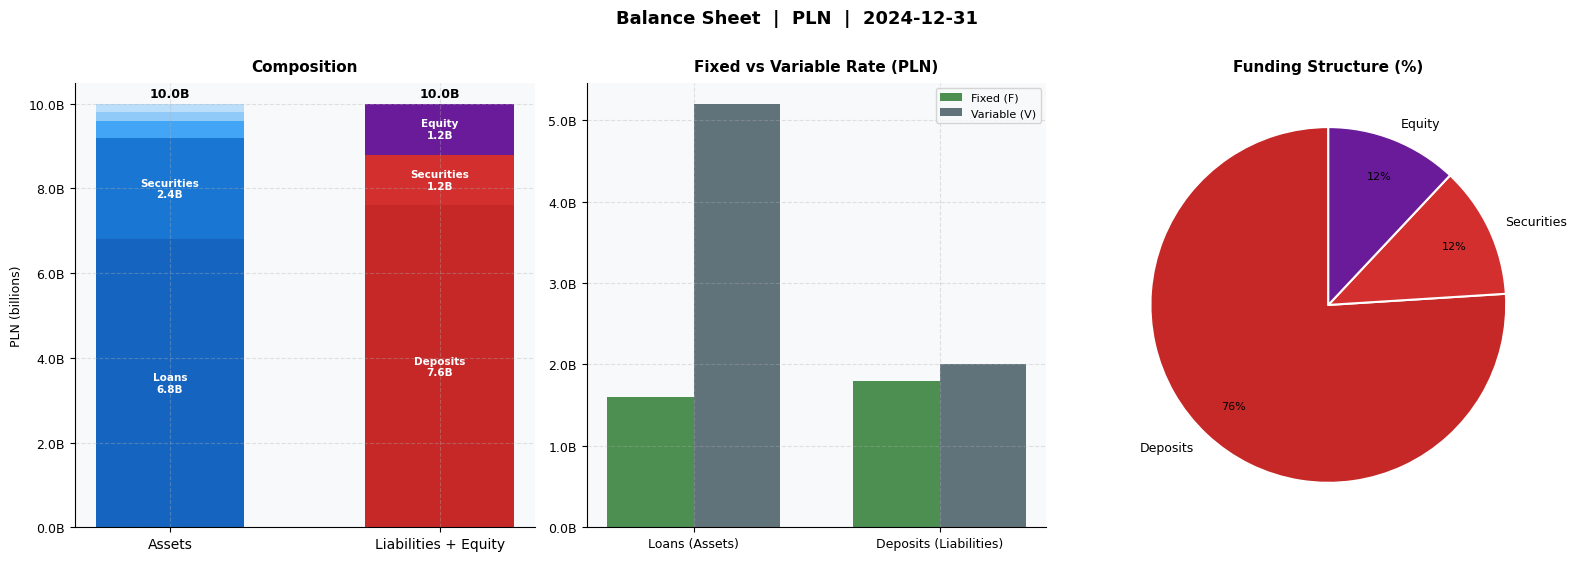


  BALANCE SHEET  |  PLN  |  2024-12-31
  Category             Assets (M)  Liabilities (M)
  ------------------------------------------------
  Cash & Placements           200                0
  Deposits                    200            7,600
  Loans                     6,800                0
  Other                       400                0
  Securities                2,400            1,200
  Equity                                     1,200
  ------------------------------------------------
  TOTAL                    10,000           10,000


In [4]:
def bs_cat(name):
    n = str(name).lower()
    if any(k in n for k in ('loan','mortgage','overdraft','credit','leasing')): return 'Loans'
    if any(k in n for k in ('bond','security','tbill','fin_inst','treasury')): return 'Securities'
    if any(k in n for k in ('nostro','cash','placement','central','cbm','interbank')): return 'Cash & Placements'
    if any(k in n for k in ('deposit','current_account','saving','account')): return 'Deposits'
    return 'Other'

bs = bs_raw.copy()
bs['cat'] = bs['product_name'].apply(bs_cat)
pln = bs[bs['currency'] == CCY]
assets = pln[pln['bs_side'] == 'A'].groupby('cat')['balance_amt'].sum().sort_values(ascending=False)
liabs  = pln[pln['bs_side'] == 'L'].groupby('cat')['balance_amt'].sum().sort_values(ascending=False)
total_a = assets.sum()
total_l = liabs.sum() + equity_amt

# ── Figure ──────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle(f'Balance Sheet  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold', y=1.01)

# Left — T-account stacked bars
ax = axes[0]
bot_a = bot_l = 0.0
for i, (cat, val) in enumerate(assets.items()):
    ax.bar(0, val/1e9, bottom=bot_a/1e9, color=BLUES[i % len(BLUES)], width=0.55)
    if val / total_a > 0.04:
        ax.text(0, (bot_a + val/2)/1e9, f'{cat}\n{val/1e9:.1f}B',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bot_a += val
for i, (cat, val) in enumerate(liabs.items()):
    ax.bar(1, val/1e9, bottom=bot_l/1e9, color=REDS[i % len(REDS)], width=0.55)
    if val / total_l > 0.04:
        ax.text(1, (bot_l + val/2)/1e9, f'{cat}\n{val/1e9:.1f}B',
                ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
    bot_l += val
ax.bar(1, equity_amt/1e9, bottom=bot_l/1e9, color=C_EQ, width=0.55)
if equity_amt / total_l > 0.02:
    ax.text(1, (bot_l + equity_amt/2)/1e9, f'Equity\n{equity_amt/1e9:.1f}B',
            ha='center', va='center', fontsize=7.5, color='white', fontweight='bold')
ax.text(0, total_a/1e9 + 0.15, f'{total_a/1e9:.1f}B', ha='center', fontweight='bold')
ax.text(1, total_l/1e9 + 0.15, f'{total_l/1e9:.1f}B', ha='center', fontweight='bold')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Assets', 'Liabilities + Equity'], fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(bn_fmt))
ax.set_ylabel('PLN (billions)')
ax.set_title('Composition')

# Middle — Fixed vs Variable by side
ax2 = axes[1]
la = loan_rt[loan_rt['currency'] == CCY].set_index('rate_type')['balance_amt']
ld = dep_rt[dep_rt['currency'] == CCY].set_index('rate_type')['balance_amt']
x2 = np.arange(2)
w2 = 0.35
for rt, color, off, lbl in [('F', C_N, -w2/2, 'Fixed (F)'), ('V', C_GR, w2/2, 'Variable (V)')]:
    vals = [la.get(rt, 0)/1e9, ld.get(rt, 0)/1e9]
    ax2.bar(x2 + off, vals, w2, label=lbl, color=color, alpha=0.85)
ax2.set_xticks(x2)
ax2.set_xticklabels(['Loans (Assets)', 'Deposits (Liabilities)'])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(bn_fmt))
ax2.set_title('Fixed vs Variable Rate (PLN)')
ax2.legend()

# Right — Funding structure pie
ax3 = axes[2]
pie_data = pd.concat([liabs, pd.Series({'Equity': equity_amt})])
pie_colors = REDS[:len(liabs)] + [C_EQ]
wedges, texts, autotexts = ax3.pie(
    pie_data, labels=pie_data.index, autopct='%1.0f%%',
    colors=pie_colors, startangle=90, pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=1.5))
for t in autotexts: t.set_fontsize(8)
ax3.set_title('Funding Structure (%)')

plt.tight_layout()
plt.show()

# ── Summary table ────────────────────────────────────────────────────────────
print(f'\n{"="*56}')
print(f'  BALANCE SHEET  |  {CCY}  |  {REPORT_DATE.date()}')
print(f'{"="*56}')
print(f'  {"Category":<18} {"Assets (M)":>12} {"Liabilities (M)":>16}')
print(f'  {"-"*48}')
all_cats = sorted(set(list(assets.index) + list(liabs.index)))
for cat in all_cats:
    a = assets.get(cat, 0)
    l = liabs.get(cat, 0)
    print(f'  {cat:<18} {a/1e6:>12,.0f} {l/1e6:>16,.0f}')
print(f'  {"Equity":<18} {"":>12} {equity_amt/1e6:>16,.0f}')
print(f'  {"-"*48}')
print(f'  {"TOTAL":<18} {total_a/1e6:>12,.0f} {total_l/1e6:>16,.0f}')
print(f'{"="*56}')

---
### 1a. Balance Sheet — Product Detail

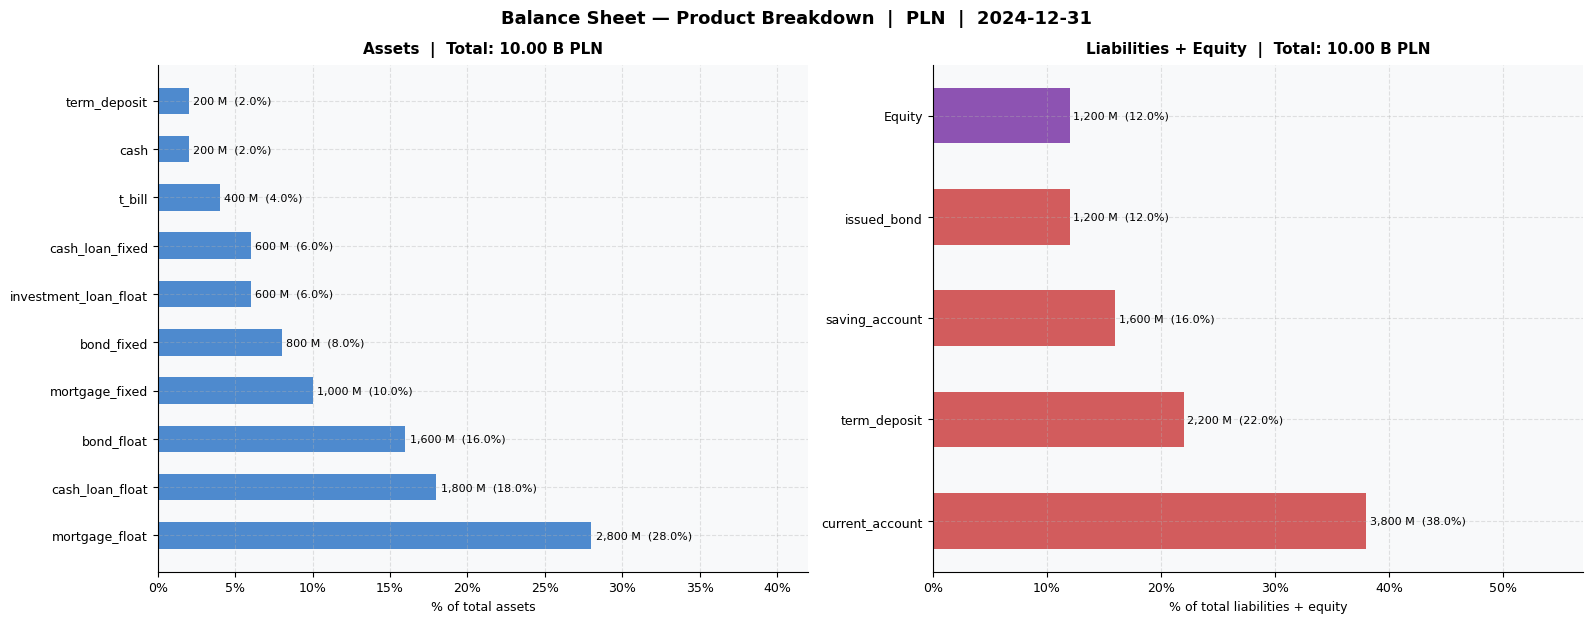


  ASSETS  |  PLN  |  2024-12-31
  Product                       Balance (M PLN)  % of Assets
  ----------------------------------------------------------
  mortgage_float                          2,800        28.0%
  cash_loan_float                         1,800        18.0%
  bond_float                              1,600        16.0%
  mortgage_fixed                          1,000        10.0%
  bond_fixed                                800         8.0%
  investment_loan_float                     600         6.0%
  cash_loan_fixed                           600         6.0%
  t_bill                                    400         4.0%
  cash                                      200         2.0%
  term_deposit                              200         2.0%
  TOTAL                                  10,000       100.0%

  LIABILITIES + EQUITY  |  PLN
  Product                       Balance (M PLN)   % of L+E
  ----------------------------------------------------------
  current_account     

In [5]:
# ─────────────────────────────────────────────────────────────────────────────
# BALANCE SHEET — PRODUCT DETAIL  (notional + % per product)
# ─────────────────────────────────────────────────────────────────────────────
pln_prod = bs_raw[bs_raw['currency'] == CCY].copy()
pln_prod_a = pln_prod[pln_prod['bs_side'] == 'A'].sort_values('balance_amt', ascending=False)
pln_prod_l = pln_prod[pln_prod['bs_side'] == 'L'].sort_values('balance_amt', ascending=False)

tot_a_p = pln_prod_a['balance_amt'].sum()
tot_l_p = pln_prod_l['balance_amt'].sum() + equity_amt

pln_prod_a = pln_prod_a.assign(pct=lambda d: d['balance_amt'] / tot_a_p * 100)
pln_prod_l = pln_prod_l.assign(pct=lambda d: d['balance_amt'] / tot_l_p * 100)
eq_pct_p   = equity_amt / tot_l_p * 100

n_a = len(pln_prod_a)
n_l = len(pln_prod_l) + 1  # +1 for equity
fig_h = max(5, max(n_a, n_l) * 0.48 + 1.5)
fig, (ax_a, ax_l) = plt.subplots(1, 2, figsize=(16, fig_h))
fig.suptitle(f'Balance Sheet — Product Breakdown  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold')

# ── Assets ──────────────────────────────────────────────────────────────────
y_a = np.arange(n_a)
ax_a.barh(y_a, pln_prod_a['pct'], color=C_A, alpha=0.75, height=0.55)
ax_a.set_yticks(y_a)
ax_a.set_yticklabels(pln_prod_a['product_name'].tolist(), fontsize=9)
ax_a.set_xlabel('% of total assets')
ax_a.set_title(f'Assets  |  Total: {tot_a_p/1e9:.2f} B PLN', fontsize=11, fontweight='bold')
ax_a.axvline(0, color='black', lw=0.5)
ax_a.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
for i, (_, r) in enumerate(pln_prod_a.iterrows()):
    ax_a.text(r['pct'] + 0.3, i,
              f'{r["balance_amt"]/1e6:,.0f} M  ({r["pct"]:.1f}%)',
              va='center', fontsize=8)
ax_a.set_xlim(0, pln_prod_a['pct'].max() * 1.5)

# ── Liabilities + Equity ─────────────────────────────────────────────────────
l_names  = pln_prod_l['product_name'].tolist() + ['Equity']
l_pcts   = pln_prod_l['pct'].tolist()         + [eq_pct_p]
l_bals   = pln_prod_l['balance_amt'].tolist()  + [equity_amt]
l_colors = [C_L] * len(pln_prod_l) + [C_EQ]

y_l = np.arange(len(l_names))
ax_l.barh(y_l, l_pcts, color=l_colors, alpha=0.75, height=0.55)
ax_l.set_yticks(y_l)
ax_l.set_yticklabels(l_names, fontsize=9)
ax_l.set_xlabel('% of total liabilities + equity')
ax_l.set_title(f'Liabilities + Equity  |  Total: {tot_l_p/1e9:.2f} B PLN',
               fontsize=11, fontweight='bold')
ax_l.axvline(0, color='black', lw=0.5)
ax_l.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
for i, (nm, pct_v, bal) in enumerate(zip(l_names, l_pcts, l_bals)):
    ax_l.text(pct_v + 0.3, i,
              f'{bal/1e6:,.0f} M  ({pct_v:.1f}%)',
              va='center', fontsize=8)
ax_l.set_xlim(0, max(l_pcts) * 1.5)

plt.tight_layout()
plt.show()

# ── Print table ──────────────────────────────────────────────────────────────
print(f'\n{"="*68}')
print(f'  ASSETS  |  {CCY}  |  {REPORT_DATE.date()}')
print(f'  {"Product":<28} {"Balance (M PLN)":>16} {"% of Assets":>12}')
print(f'  {"-"*58}')
for _, r in pln_prod_a.iterrows():
    print(f'  {r["product_name"]:<28} {r["balance_amt"]/1e6:>16,.0f} {r["pct"]:>11.1f}%')
print(f'  {"TOTAL":<28} {tot_a_p/1e6:>16,.0f} {"100.0%":>12}')
print(f'\n  LIABILITIES + EQUITY  |  {CCY}')
print(f'  {"Product":<28} {"Balance (M PLN)":>16} {"% of L+E":>10}')
print(f'  {"-"*58}')
for _, r in pln_prod_l.iterrows():
    print(f'  {r["product_name"]:<28} {r["balance_amt"]/1e6:>16,.0f} {r["pct"]:>9.1f}%')
print(f'  {"Equity":<28} {equity_amt/1e6:>16,.0f} {eq_pct_p:>9.1f}%')
print(f'  {"TOTAL":<28} {tot_l_p/1e6:>16,.0f} {"100.0%":>10}')
print(f'{"="*68}')


---
## 2. Market Yield Curves

Base discount / forward curves as of the report date. Decreasing discount factors or negative zero rates indicate inverted segments.

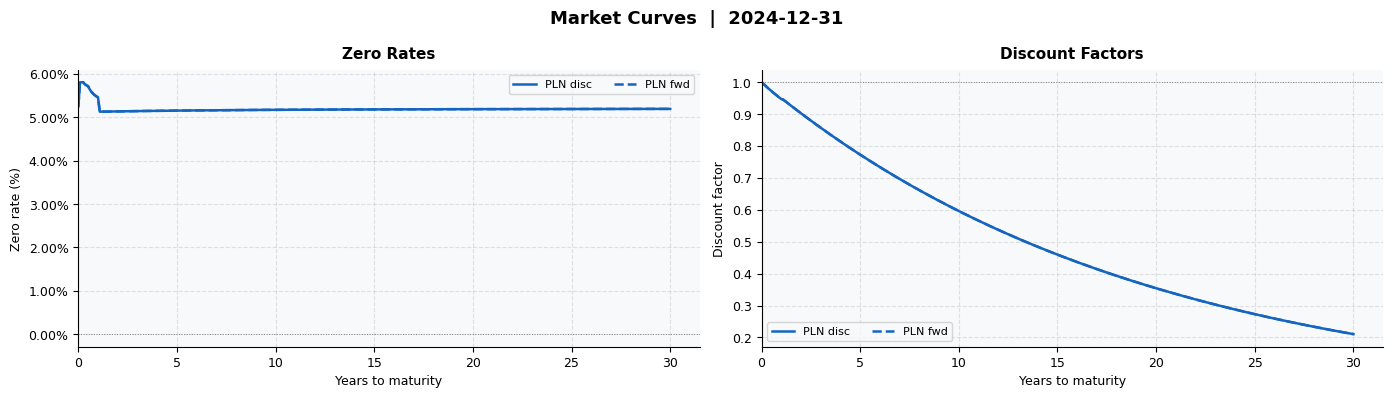

In [6]:
CURVE_STYLE = {
    'PLN_disc_curve': ('#1565C0', '-',  'PLN disc'),
    'PLN_fwd_curve':  ('#1565C0', '--', 'PLN fwd'),
    'EUR_disc_curve': ('#E65100', '-',  'EUR disc'),
    'EUR_fwd_curve':  ('#E65100', '--', 'EUR fwd'),
    'USD_disc_curve': ('#2E7D32', '-',  'USD disc'),
    'USD_fwd_curve':  ('#2E7D32', '--', 'USD fwd'),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f'Market Curves  |  {REPORT_DATE.date()}', fontsize=13, fontweight='bold')

for curve_name, grp in mkt.groupby('curve_name'):
    grp = grp.sort_values('n_days')
    if grp['zero_rate'].isna().all(): continue
    col, ls, lbl = CURVE_STYLE.get(curve_name, (C_GR, '-', curve_name))
    x_yr = grp['n_days'] / 365.25
    ax1.plot(x_yr, grp['zero_rate'] * 100, color=col, linestyle=ls, linewidth=1.8, label=lbl)
    ax2.plot(x_yr, grp['d_f'], color=col, linestyle=ls, linewidth=1.8, label=lbl)

ax1.axhline(0, color='grey', linewidth=0.7, linestyle=':')
ax1.set_xlabel('Years to maturity')
ax1.set_ylabel('Zero rate (%)')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
ax1.set_xlim(left=0)
ax1.set_title('Zero Rates')
ax1.legend(ncol=2)

ax2.axhline(1, color='grey', linewidth=0.7, linestyle=':')
ax2.set_xlabel('Years to maturity')
ax2.set_ylabel('Discount factor')
ax2.set_xlim(left=0)
ax2.set_title('Discount Factors')
ax2.legend(ncol=2)

plt.tight_layout()
plt.show()

---
## 2b. IRRBB Scenario Yield Curves

EBA SOT shocked zero rates applied to the PLN discount curve for the 6 supervisory scenarios (EBA/RTS/2022/10 Article 3).
The **base** curve (bold black) is the current market rate.
Shock magnitudes for PLN: parallel ±250 bps, short-rate ±350 bps, long-rate ±150 bps.


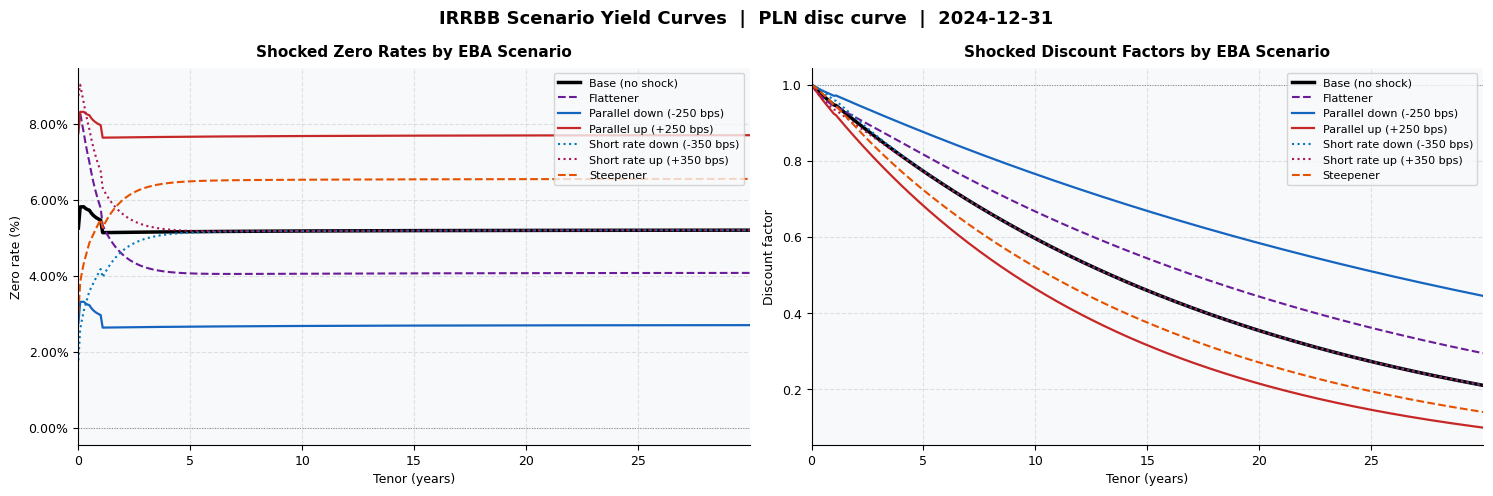

In [7]:
# ─────────────────────────────────────────────────────────────────────────────
# IRRBB SCENARIO YIELD CURVES  — base + 6 EBA SOT on PLN disc curve
# ─────────────────────────────────────────────────────────────────────────────
_SCEN_STYLE = {
    'base':   ('#000000', '-',  2.5, 'Base (no shock)'),
    'par_up': ('#C62828', '-',  1.6, 'Parallel up (+250 bps)'),
    'par_dn': ('#1565C0', '-',  1.6, 'Parallel down (-250 bps)'),
    'steep':  ('#E65100', '--', 1.5, 'Steepener'),
    'flat':   ('#6A1B9A', '--', 1.5, 'Flattener'),
    'sr_up':  ('#AD1457', ':',  1.5, 'Short rate up (+350 bps)'),
    'sr_dn':  ('#0277BD', ':',  1.5, 'Short rate down (-350 bps)'),
}

if irrbb_curves.empty:
    print('IRRBB scenario curves not available. Run nii_calc_workflow first.')
else:
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'IRRBB Scenario Yield Curves  |  PLN disc curve  |  {REPORT_DATE.date()}',
                 fontsize=13, fontweight='bold')

    _max_yr = irrbb_curves['n_days'].max() / 365.25

    for sid, grp in irrbb_curves.groupby('scenario_id'):
        grp = grp.sort_values('n_days')
        col, ls, lw, lbl = _SCEN_STYLE.get(sid, ('#888888', '-', 1.2, sid))
        t_yr = grp['n_days'] / 365.25
        if 'zero_rt' in grp.columns and grp['zero_rt'].notna().any():
            zr = grp['zero_rt'] * 100
        else:
            _t  = t_yr.to_numpy()
            _df = grp['d_f'].to_numpy()
            with np.errstate(divide='ignore', invalid='ignore'):
                zr = np.where(_t > 0, -np.log(np.clip(_df, 1e-12, None)) / _t * 100, 0.0)
        ax1.plot(t_yr, zr,           color=col, ls=ls, lw=lw, label=lbl)
        ax2.plot(t_yr, grp['d_f'],   color=col, ls=ls, lw=lw, label=lbl)

    ax1.axhline(0, color='grey', lw=0.7, ls=':')
    ax1.set_xlabel('Tenor (years)'); ax1.set_ylabel('Zero rate (%)')
    ax1.set_title('Shocked Zero Rates by EBA Scenario')
    ax1.set_xlim(0, _max_yr)
    ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.2f}%'))
    ax1.legend(fontsize=8, loc='upper right')

    ax2.axhline(1, color='grey', lw=0.7, ls=':')
    ax2.set_xlabel('Tenor (years)'); ax2.set_ylabel('Discount factor')
    ax2.set_title('Shocked Discount Factors by EBA Scenario')
    ax2.set_xlim(0, _max_yr)
    ax2.legend(fontsize=8, loc='upper right')

    plt.tight_layout()
    plt.show()


---
## 3. Interest Rate Repricing Gap

Net repricing gap = Σ asset CFs − Σ liability CFs falling in each tenor bucket.  
A **positive gap** means more assets reprice than liabilities → NII benefits from rising rates.  
A **negative gap** (liability-sensitive) → NII benefits from falling rates.  
`gap_cf_irs` = IRS contribution (from ir_derivatives workflow).

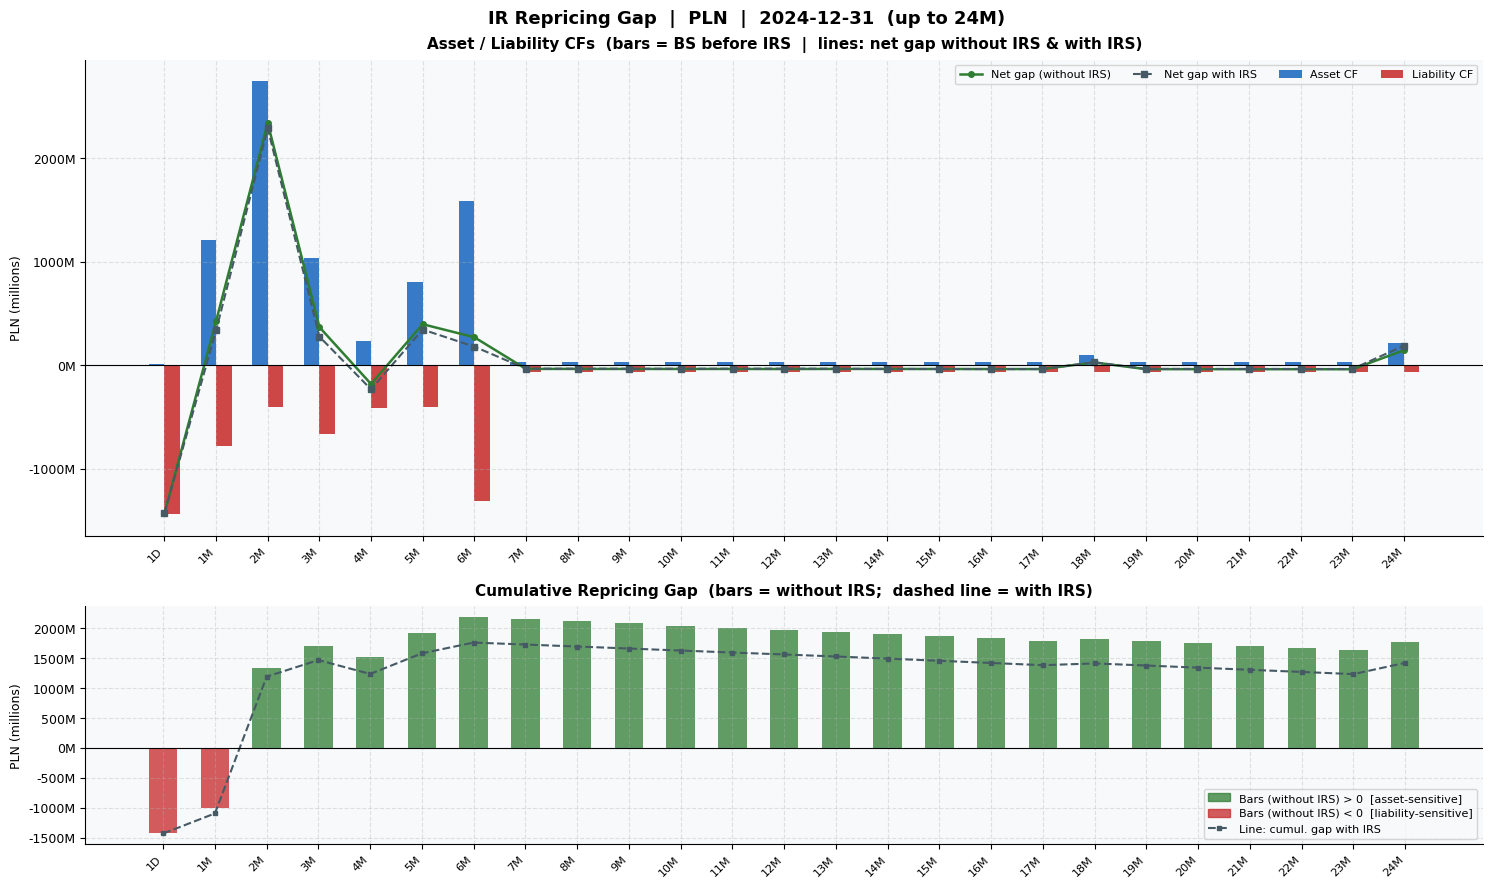


  Bucket     Asset CF      Liab CF    Net (BS)        IRS    Net+IRS     Cum Net
  ----------------------------------------------------------------------------
  1D                8       -1,439      -1,430          0     -1,430      -1,430
  1M            1,209         -783         426        -90        336      -1,004
  2M            2,742         -403       2,339        -51      2,288       1,335
  3M            1,034         -665         369        -92        277       1,704
  4M              234         -415        -181        -51       -232       1,523
  5M              800         -403         396        -51        345       1,919
  6M            1,584       -1,314         271        -91        180       2,190
  7M               34          -69         -35          2        -33       2,155
  8M               34          -69         -35          2        -33       2,120
  9M               33          -69         -36          2        -34       2,084
  10M              33        

In [8]:
g = ir_gap[ir_gap['currency'] == CCY].copy()

# Net gap (signed: A=+, L=-) and IRS
net_bs  = g.groupby('tenor_bucket')[['gap_cf', 'gap_cf_irs']].sum().reset_index()
net_bs['net_total'] = net_bs['gap_cf'] + net_bs['gap_cf_irs']

# Separate asset and liability for waterfall bars
a_gap = (g[g['bs_side'] == 'A'].groupby('tenor_bucket')['gap_cf']
         .sum().rename('asset_cf').reset_index())
l_gap = (g[g['bs_side'] == 'L'].groupby('tenor_bucket')['gap_cf']
         .sum().rename('liab_cf').reset_index())

gap_df = (net_bs
          .merge(a_gap, on='tenor_bucket', how='outer')
          .merge(l_gap, on='tenor_bucket', how='outer')
          .fillna(0.0))
gap_df = sbkt(gap_df)
gap_df['cum_net']   = gap_df['gap_cf'].cumsum()
gap_df['cum_total'] = gap_df['net_total'].cumsum()

# Limit detail display to <=24M
MAX_M = 24
gp = gap_df[gap_df['tenor_bucket'].map(tkey) <= MAX_M].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9),
                                gridspec_kw={'height_ratios': [2, 1]})
fig.suptitle(f'IR Repricing Gap  |  {CCY}  |  {REPORT_DATE.date()}  (up to 24M)',
             fontsize=13, fontweight='bold')

labels = gp['tenor_bucket'].tolist()
x = np.arange(len(labels))
w = 0.3

# Upper: asset / liability / net
ax1.bar(x - w/2, gp['asset_cf']/1e6, w, label='Asset CF',     color=C_A, alpha=0.85)
ax1.bar(x + w/2, gp['liab_cf']/1e6,  w, label='Liability CF', color=C_L, alpha=0.85)
ax1.plot(x, gp['gap_cf']/1e6,    color=C_N,  marker='o', ms=4, lw=1.8, label='Net gap (without IRS)')
ax1.plot(x, gp['net_total']/1e6, color=C_GR, marker='s', ms=4, lw=1.5,
         linestyle='--', label='Net gap with IRS')
ax1.axhline(0, color='black', lw=0.8)
ax1.set_xticks(x)
ax1.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax1.set_ylabel('PLN (millions)')
ax1.set_title('Asset / Liability CFs  '
              '(bars = BS before IRS  |  lines: net gap without IRS & with IRS)')
ax1.legend(ncol=4)

# Lower: cumulative gap
bar_colors = [C_N if v >= 0 else C_L for v in gp['cum_net']]
ax2.bar(x, gp['cum_net']/1e6,   color=bar_colors, alpha=0.75, width=0.55)
ax2.plot(x, gp['cum_total']/1e6, color=C_GR, lw=1.5, linestyle='--',
         marker='s', ms=3, label='Cumul. net with IRS')
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x)
ax2.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax2.set_ylabel('PLN (millions)')
ax2.set_title('Cumulative Repricing Gap  '
              '(bars = without IRS;  dashed line = with IRS)')
# Explicit legend for colour coding
_p_pos = mpatches.Patch(color=C_N, alpha=0.75,
                         label='Bars (without IRS) > 0  [asset-sensitive]')
_p_neg = mpatches.Patch(color=C_L, alpha=0.75,
                         label='Bars (without IRS) < 0  [liability-sensitive]')
_p_irs = plt.Line2D([0],[0], color=C_GR, lw=1.5, linestyle='--',
                    marker='s', ms=3, label='Line: cumul. gap with IRS')
ax2.legend(handles=[_p_pos, _p_neg, _p_irs], fontsize=8)

plt.tight_layout()
plt.show()

# -- Table -----------------------------------------------------------------------
print(f'\n  {"Bucket":<6} {"Asset CF":>12} {"Liab CF":>12} {"Net (BS)":>11} '
      f'{"IRS":>10} {"Net+IRS":>10} {"Cum Net":>11}')
print(f'  {"-"*76}')
for _, r in gp.iterrows():
    print(f'  {r["tenor_bucket"]:<6} {r["asset_cf"]/1e6:>12,.0f} {r["liab_cf"]/1e6:>12,.0f} '
          f'{r["gap_cf"]/1e6:>11,.0f} {r["gap_cf_irs"]/1e6:>10,.0f} '
          f'{r["net_total"]/1e6:>10,.0f} {r["cum_net"]/1e6:>11,.0f}')

# Totals beyond 24M
beyond = gap_df[gap_df['tenor_bucket'].map(tkey) > MAX_M]
if not beyond.empty:
    print(f'  {">24M":<6} {beyond["asset_cf"].sum()/1e6:>12,.0f} '
          f'{beyond["liab_cf"].sum()/1e6:>12,.0f} {beyond["gap_cf"].sum()/1e6:>11,.0f}')
print(f'  {"-"*76}')
print(f'  {"TOTAL":<6} {gap_df["asset_cf"].sum()/1e6:>12,.0f} '
      f'{gap_df["liab_cf"].sum()/1e6:>12,.0f} {gap_df["gap_cf"].sum()/1e6:>11,.0f} '
      f'{gap_df["gap_cf_irs"].sum()/1e6:>10,.0f} {gap_df["net_total"].sum()/1e6:>10,.0f}')


### 3a. IRS Book Repricing Profile

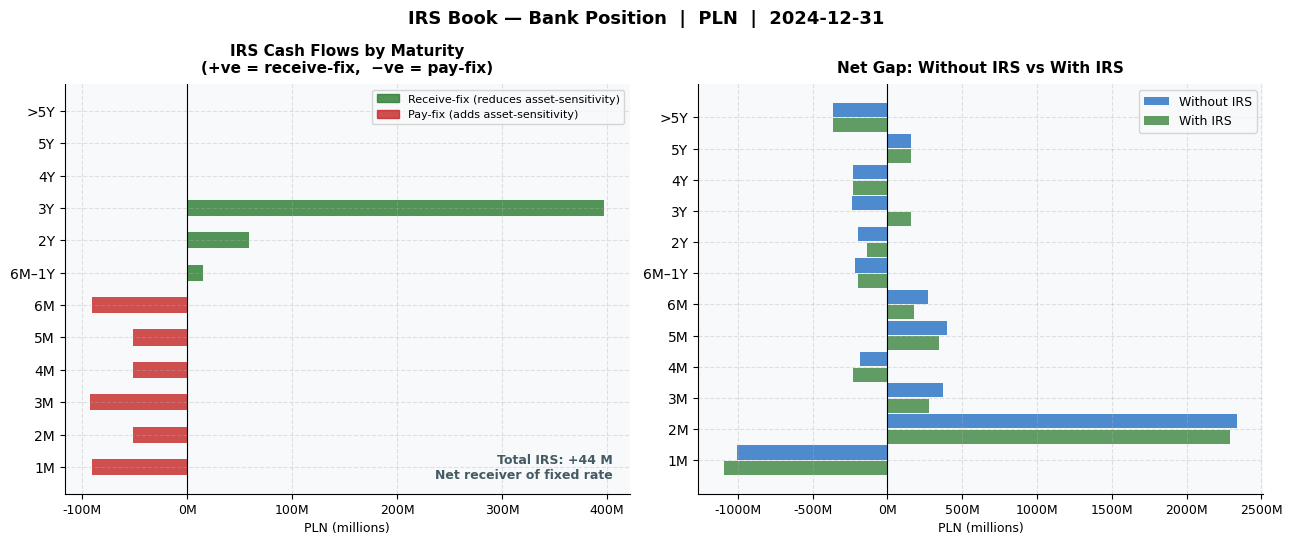


  IRS REPRICING SUMMARY  |  PLN
  Bucket     BS Gap (M)   IRS CF (M)  Net+IRS (M)  Effect
  --------------------------------------------------------------
  1D             -1,430            0        -1,430  —
  1M                426          -90           336  hedges gap
  2M              2,339          -51         2,288  hedges gap
  3M                369          -92           277  hedges gap
  4M               -181          -51          -232  amplifies gap
  5M                396          -51           345  hedges gap
  6M                271          -91           180  hedges gap
  7M                -35            2           -33  hedges gap
  8M                -35            2           -33  hedges gap
  9M                -36            2           -34  hedges gap
  10M               -36            2           -34  hedges gap
  11M               -36            2           -33  hedges gap
  12M               -36            4           -32  hedges gap
  13M               -35        

In [9]:
# -------------------------------------------------------------------
# IRS BOOK POSITION  -- monthly up to 6M, then 6M-1Y, then annual to 5Y
# -------------------------------------------------------------------
g_irs = ir_gap[ir_gap['currency'] == CCY].copy()
irs_df = (g_irs.groupby('tenor_bucket')[['gap_cf', 'gap_cf_irs']]
          .sum().reset_index())
irs_df['net_total'] = irs_df['gap_cf'] + irs_df['gap_cf_irs']
irs_df = sbkt(irs_df)

# Group into fine monthly buckets up to 6M, then 6M-1Y, then annual
def _irs_grp(tb):
    m = tkey(tb)
    if m <=  1:  return '1M'
    if m <=  2:  return '2M'
    if m <=  3:  return '3M'
    if m <=  4:  return '4M'
    if m <=  5:  return '5M'
    if m <=  6:  return '6M'
    if m <= 12:  return '6M–1Y'
    if m <= 24:  return '2Y'
    if m <= 36:  return '3Y'
    if m <= 48:  return '4Y'
    if m <= 60:  return '5Y'
    return '>5Y'

irs_df['grp'] = irs_df['tenor_bucket'].map(_irs_grp)
GRP_ORDER = ['1M', '2M', '3M', '4M', '5M', '6M', '6M–1Y',
             '2Y', '3Y', '4Y', '5Y', '>5Y']
irs_grp = (irs_df.groupby('grp')[['gap_cf', 'gap_cf_irs', 'net_total']]
           .sum().reindex([g for g in GRP_ORDER if g in irs_df['grp'].unique()]))

fig, (axI1, axI2) = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle(f'IRS Book — Bank Position  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold')

y_g = np.arange(len(irs_grp))
h   = 0.5

# Left: IRS CFs by grouped maturity -- horizontal bars
irs_clrs = [C_N if v >= 0 else C_L for v in irs_grp['gap_cf_irs']]
axI1.barh(y_g, irs_grp['gap_cf_irs'] / 1e6, height=h, color=irs_clrs, alpha=0.82)
axI1.axvline(0, color='black', lw=0.8)
axI1.set_yticks(y_g)
axI1.set_yticklabels(irs_grp.index, fontsize=10)
axI1.xaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
axI1.set_xlabel('PLN (millions)')
axI1.set_title('IRS Cash Flows by Maturity\n(+ve = receive-fix,  −ve = pay-fix)')
_p_rec = mpatches.Patch(color=C_N, alpha=0.82, label='Receive-fix (reduces asset-sensitivity)')
_p_pay = mpatches.Patch(color=C_L, alpha=0.82, label='Pay-fix (adds asset-sensitivity)')
axI1.legend(handles=[_p_rec, _p_pay], fontsize=8)
total_irs = irs_grp['gap_cf_irs'].sum()
direction = 'Net receiver of fixed rate' if total_irs >= 0 else 'Net payer of fixed rate'
axI1.text(0.97, 0.03, f'Total IRS: {total_irs/1e6:+,.0f} M\n{direction}',
          transform=axI1.transAxes, ha='right', va='bottom',
          fontsize=9, fontweight='bold', color=C_GR)

# Right: Gap without IRS vs with IRS -- paired horizontal bars
axI2.barh(y_g + h/2, irs_grp['gap_cf'] / 1e6,    h * 0.9,
          label='Without IRS', color=C_A, alpha=0.75)
axI2.barh(y_g - h/2, irs_grp['net_total'] / 1e6,  h * 0.9,
          label='With IRS',    color=C_N, alpha=0.75)
axI2.axvline(0, color='black', lw=0.8)
axI2.set_yticks(y_g)
axI2.set_yticklabels(irs_grp.index, fontsize=10)
axI2.xaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
axI2.set_xlabel('PLN (millions)')
axI2.set_title('Net Gap: Without IRS vs With IRS')
axI2.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Detailed IRS summary table (per original tenor bucket)
print(f'\n  IRS REPRICING SUMMARY  |  {CCY}')
print(f'  {"Bucket":<8} {"BS Gap (M)":>12} {"IRS CF (M)":>12} {"Net+IRS (M)":>12}  Effect')
print(f'  {"-"*62}')
for _, r in irs_df.iterrows():
    if abs(r['gap_cf_irs']) < 0.5:
        effect = '—'
    elif (r['gap_cf'] > 0 and r['gap_cf_irs'] < 0) or (r['gap_cf'] < 0 and r['gap_cf_irs'] > 0):
        effect = 'hedges gap'
    else:
        effect = 'amplifies gap'
    print(f'  {r["tenor_bucket"]:<8} {r["gap_cf"]/1e6:>12,.0f} {r["gap_cf_irs"]/1e6:>12,.0f} ',
          f'{r["net_total"]/1e6:>12,.0f}  {effect}')
print(f'  {"-"*62}')
print(f'  {"TOTAL":<8} {irs_df["gap_cf"].sum()/1e6:>12,.0f} ',
      f'{irs_df["gap_cf_irs"].sum()/1e6:>12,.0f} ',
      f'{irs_df["net_total"].sum()/1e6:>12,.0f}')
bs_sens  = "asset-sensitive" if irs_df["gap_cf"].sum() > 0 else "liability-sensitive"
net_sens = "asset-sensitive" if irs_df["net_total"].sum() > 0 else "liability-sensitive"
print(f'\n  BS (before IRS): {bs_sens}  →  After IRS: {net_sens}')


### 3b. IR Gap by Product Group

Stacked repricing gap by broad product category (assets above zero, liabilities below zero), using the same tenor grouping as the IRS view. Isolates the contribution of each product segment to the bank's interest rate exposure.

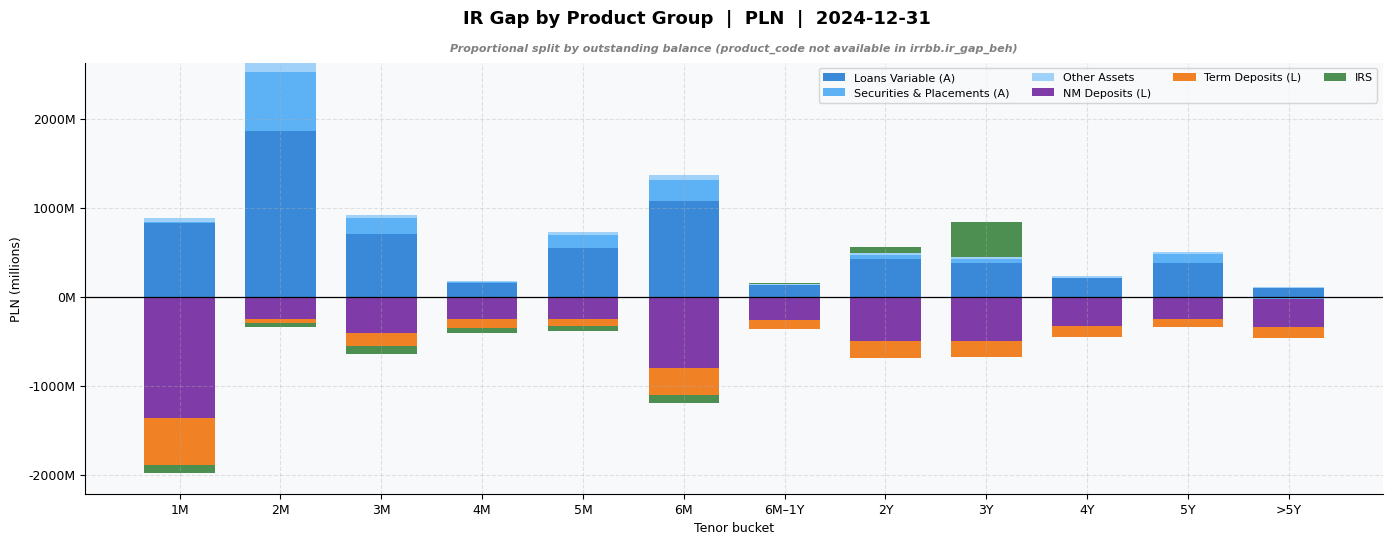

In [10]:
# -------------------------------------------------------------------
# IR GAP BY PRODUCT GROUP
# Groups by product_code from irrbb.ir_gap_beh joined to
# dbo.transactions for product_name + rate_type.
# Fallback: proportional allocation via outstanding_bal.
# -------------------------------------------------------------------

def _tgrp(tb):
    m = tkey(tb)
    if m <=  1:  return '1M'
    if m <=  2:  return '2M'
    if m <=  3:  return '3M'
    if m <=  4:  return '4M'
    if m <=  5:  return '5M'
    if m <=  6:  return '6M'
    if m <= 12:  return '6M–1Y'
    if m <= 24:  return '2Y'
    if m <= 36:  return '3Y'
    if m <= 48:  return '4Y'
    if m <= 60:  return '5Y'
    return '>5Y'

TGRP_ORDER = ['1M','2M','3M','4M','5M','6M','6M–1Y',
              '2Y','3Y','4Y','5Y','>5Y']

GRP_DEF = [
    ('Loans Fixed (A)',             '#0D47A1'),
    ('Loans Variable (A)',          '#1976D2'),
    ('Securities & Placements (A)', '#42A5F5'),
    ('Other Assets',                '#90CAF9'),
    ('NM Deposits (L)',             '#6A1B9A'),
    ('Term Deposits (L)',           '#EF6C00'),
    ('Other Liabilities',           '#FFCDD2'),
    ('IRS',                         '#2E7D32'),
]
grp_clrs = {g: c for g, c in GRP_DEF}

def _pg(pn, bs, rt='V'):
    """Map product_name + bs_side + rate_type to display group."""
    pn = str(pn).lower();  bs = str(bs).upper();  rt = str(rt).upper()
    if any(k in pn for k in ('loan','mortgage','overdraft','leasing','credit')):
        return 'Loans Fixed (A)' if rt == 'F' else 'Loans Variable (A)'
    if any(k in pn for k in ('bond','security','tbill','treasury',
                              'placement','nostro','cash','interbank','cbm')):
        return 'Securities & Placements (A)'
    if any(k in pn for k in ('current_account','saving','saving_account','demand')):
        return 'NM Deposits (L)'
    if any(k in pn for k in ('deposit','term','account')):
        return 'Term Deposits (L)'
    return 'Other Assets' if bs == 'A' else 'Other Liabilities'

pivot    = None
_src_lbl = ''

# ── Attempt 1: product_code in ir_gap_beh joined to dbo.transactions ────────
# Join gives product_name and rate_type per product_code so Fixed/Float
# loan split is exact, not proportional.
try:
    _raw = rsql('''
        SELECT g.currency,
               g.bs_side,
               g.product_code,
               ISNULL(t.product_name, CAST(g.product_code AS NVARCHAR)) AS product_name,
               ISNULL(t.rate_type,    'V')                               AS rate_type,
               g.tenor_bucket,
               SUM(g.gap_cf)                AS gap_cf,
               SUM(ISNULL(g.gap_cf_irs,0))  AS gap_cf_irs
        FROM irrbb.ir_gap_beh g
        LEFT JOIN (
            SELECT product_code,
                   MAX(product_name)            AS product_name,
                   MAX(ISNULL(rate_type, 'V'))  AS rate_type
            FROM dbo.transactions
            WHERE report_date = :rd
            GROUP BY product_code
        ) t ON g.product_code = t.product_code
        GROUP BY g.currency, g.bs_side, g.product_code,
                 t.product_name, t.rate_type, g.tenor_bucket
    ''', rd=RD)
    _g2 = _raw[_raw['currency'] == CCY].copy()
    _g2['prod_grp'] = _g2.apply(
        lambda r: _pg(r['product_name'], r['bs_side'], r['rate_type']), axis=1)
    _g2['tgrp'] = _g2['tenor_bucket'].map(_tgrp)
    # IRS contribution as separate group
    _irs = _g2[_g2['gap_cf_irs'] != 0][['tgrp','gap_cf_irs']].copy()
    _irs.columns    = ['tgrp','gap_cf']
    _irs['prod_grp'] = 'IRS'
    _comb = pd.concat([_g2[['tgrp','prod_grp','gap_cf']], _irs],
                      ignore_index=True)
    pivot = (_comb.groupby(['tgrp','prod_grp'])['gap_cf']
             .sum().unstack(fill_value=0))
    pivot = pivot.reindex([t for t in TGRP_ORDER if t in pivot.index])
    _src_lbl = ''
except Exception as _e:
    pivot = None

# ── Attempt 2: proportional allocation from outstanding_bal ─────────────────
# Used when ir_gap_beh does not expose product_code.
# Loan F/V split uses loan_rt balance weights (already in memory).
if pivot is None:
    _obs = outstanding_bal[outstanding_bal['currency'] == CCY].copy()
    _obs['prod_grp'] = _obs.apply(
        lambda r: _pg(r.get('product_name',''), r.get('bs_side','')), axis=1)
    # Re-split generic 'Loans (A)' into Fixed/Variable using loan_rt weights
    _lr   = loan_rt[loan_rt['currency'] == CCY].set_index('rate_type')['balance_amt']
    _ltot = max(_lr.sum(), 1)
    _fw   = float(_lr.get('F', 0)) / _ltot
    _vw   = float(_lr.get('V', 0)) / _ltot
    if _fw + _vw == 0: _fw, _vw = 0.5, 0.5

    _obs_exp = []
    for _, row in _obs.iterrows():
        if row['prod_grp'] in ('Loans Fixed (A)', 'Loans Variable (A)'):
            # Already split correctly via rate_type in _pg if available
            _obs_exp.append({'prod_grp': row['prod_grp'],
                             'bs_side':  row['bs_side'],
                             'balance_amt': row['balance_amt']})
        else:
            _obs_exp.append({'prod_grp': row['prod_grp'],
                             'bs_side':  row['bs_side'],
                             'balance_amt': row['balance_amt']})
    _obs2 = pd.DataFrame(_obs_exp)
    _obs_a = _obs2[_obs2['bs_side']=='A'].groupby('prod_grp')['balance_amt'].sum()
    _obs_l = _obs2[_obs2['bs_side']=='L'].groupby('prod_grp')['balance_amt'].sum()

    # Split any remaining 'Loans (A)' bucket (catch-all from _pg)
    def _expand_loans(s, fw, vw):
        if 'Loans (A)' in s.index:
            v = s.pop('Loans (A)')
            s['Loans Fixed (A)']    = s.get('Loans Fixed (A)', 0)    + v * fw
            s['Loans Variable (A)'] = s.get('Loans Variable (A)', 0) + v * vw
        return s
    _obs_a = _expand_loans(_obs_a.copy(), _fw, _vw)

    _a_tot = max(_obs_a.sum(), 1)
    _l_tot = max(_obs_l.sum(), 1)

    _g = ir_gap[ir_gap['currency'] == CCY].copy()
    _g['tgrp'] = _g['tenor_bucket'].map(_tgrp)
    _gap_bs = _g.groupby(['bs_side','tgrp'])[['gap_cf','gap_cf_irs']].sum()

    _rows = []
    for (_bs, _tg), _row in _gap_bs.iterrows():
        _gap, _irs_cf = _row['gap_cf'], _row['gap_cf_irs']
        _side = _obs_a if _bs == 'A' else _obs_l
        _tot  = _a_tot  if _bs == 'A' else _l_tot
        if _side.empty:
            _rows.append({'tgrp': _tg,
                          'prod_grp': 'Other Assets' if _bs=='A' else 'Other Liabilities',
                          'gap_cf': _gap})
        else:
            for _pg_name, _bal in _side.items():
                _rows.append({'tgrp': _tg, 'prod_grp': _pg_name,
                              'gap_cf': _gap * _bal / _tot})
        if _irs_cf != 0:
            _rows.append({'tgrp': _tg, 'prod_grp': 'IRS', 'gap_cf': _irs_cf})

    if _rows:
        _df  = pd.DataFrame(_rows)
        pivot = (_df.groupby(['tgrp','prod_grp'])['gap_cf']
                 .sum().unstack(fill_value=0))
        pivot = pivot.reindex([t for t in TGRP_ORDER if t in pivot.index])
    _src_lbl = (
        'Proportional split by outstanding balance '
        '(product_code not available in irrbb.ir_gap_beh)'
    )

# ── Plot ────────────────────────────────────────────────────────────────────
if pivot is not None and not pivot.empty:
    grp_names = [g for g, _ in GRP_DEF if g in pivot.columns]
    x_p = np.arange(len(pivot))

    fig, ax = plt.subplots(figsize=(14, 5.5))
    _title = f'IR Gap by Product Group  |  {CCY}  |  {REPORT_DATE.date()}'
    fig.suptitle(_title, fontsize=13, fontweight='bold')
    if _src_lbl:
        ax.set_title(_src_lbl, fontsize=8, color='grey', style='italic')

    pos_bot    = np.zeros(len(pivot))
    neg_bot    = np.zeros(len(pivot))
    _in_legend = set()
    for grp in grp_names:
        if grp not in pivot.columns:
            continue
        vals  = pivot[grp].values / 1e6
        pos_v = np.where(vals >= 0, vals, 0)
        neg_v = np.where(vals <  0, vals, 0)
        clr   = grp_clrs[grp]
        lbl   = grp if grp not in _in_legend else '_nolegend_'
        if pos_v.any():
            ax.bar(x_p, pos_v, bottom=pos_bot, color=clr, alpha=0.85,
                   width=0.7, label=lbl)
            pos_bot += pos_v;  _in_legend.add(grp);  lbl = '_nolegend_'
        if neg_v.any():
            ax.bar(x_p, neg_v, bottom=neg_bot, color=clr, alpha=0.85,
                   width=0.7, label=lbl)
            neg_bot += neg_v;  _in_legend.add(grp)

    ax.axhline(0, color='black', lw=0.9)
    ax.set_xticks(x_p)
    ax.set_xticklabels(pivot.index, fontsize=9)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
    ax.set_ylabel('PLN (millions)')
    ax.set_xlabel('Tenor bucket')
    ax.legend(ncol=4, fontsize=8, loc='upper right')
    plt.tight_layout()
    plt.show()
else:
    print('  No data available for IR Gap by Product Group.')


---
## 4. Liquidity Gap

Behavioural liquidity gap: asset CFs (inflows, +) vs liability CFs (outflows, −) placed at each tenor bucket.  
Cumulative gap below zero indicates a funding shortfall at that horizon.

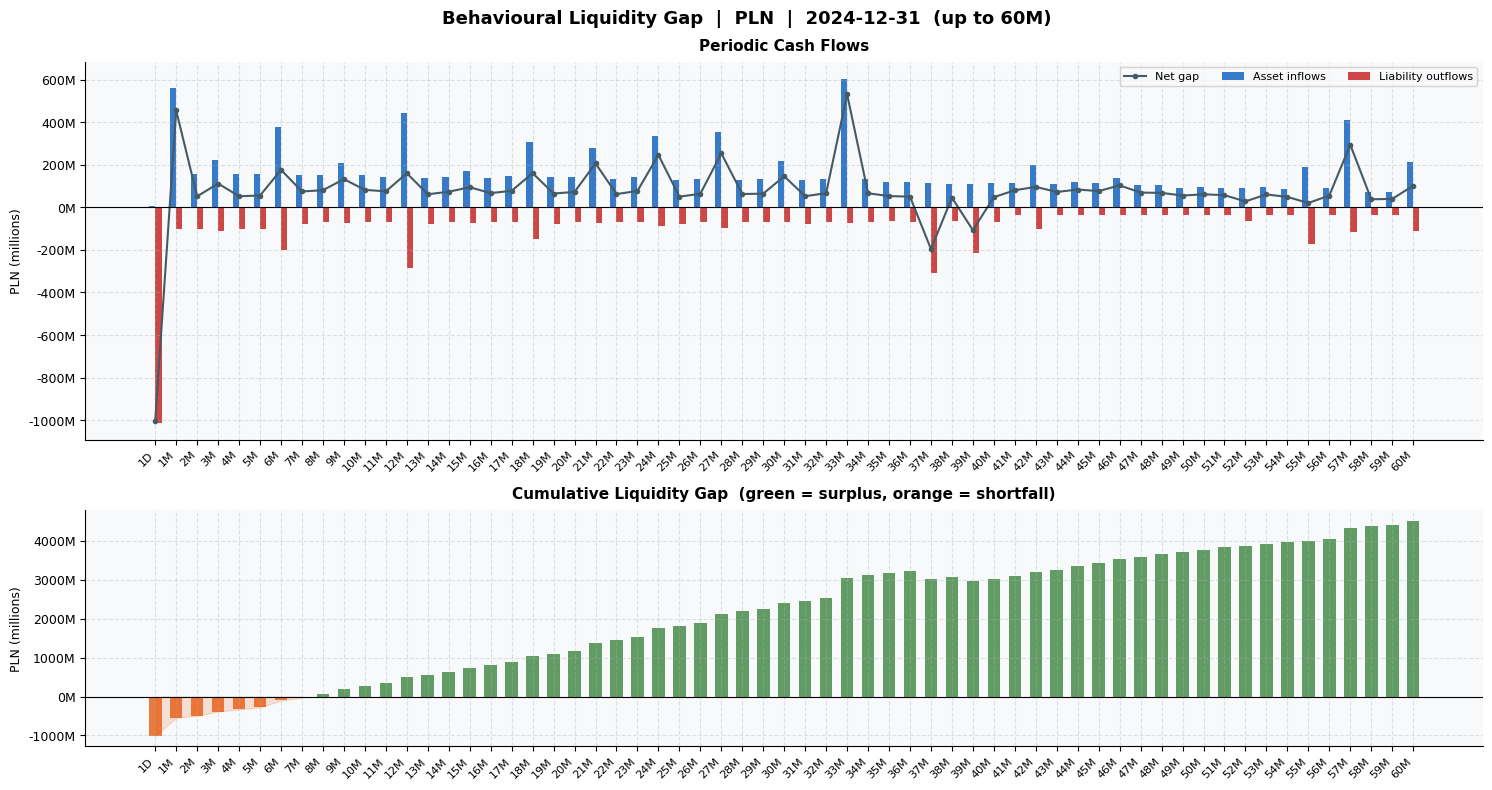


  Max surplus : 60M  →  +4,514 M PLN
  Max shortfall: 1D  →  -1,003 M PLN


In [11]:
lg = liq_gap[liq_gap['currency'] == CCY].copy()
net_liq = lg.groupby('tenor_bucket')['gap_cf'].sum().reset_index()
net_liq = sbkt(net_liq)
net_liq['cum'] = net_liq['gap_cf'].cumsum()

# Asset and liability separately
la_liq = (lg[lg['bs_side'] == 'A'].groupby('tenor_bucket')['gap_cf']
          .sum().rename('asset_cf').reset_index())
ll_liq = (lg[lg['bs_side'] == 'L'].groupby('tenor_bucket')['gap_cf']
          .sum().rename('liab_cf').reset_index())
liq_df = (net_liq
          .merge(la_liq, on='tenor_bucket', how='left')
          .merge(ll_liq, on='tenor_bucket', how='left')
          .fillna(0.0))

MAX_M_LIQ = 60
lp = liq_df[liq_df['tenor_bucket'].map(tkey) <= MAX_M_LIQ].copy()

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 8),
                                gridspec_kw={'height_ratios': [1.6, 1]})
fig.suptitle(f'Behavioural Liquidity Gap  |  {CCY}  |  {REPORT_DATE.date()}  (up to 60M)',
             fontsize=13, fontweight='bold')

labels_l = lp['tenor_bucket'].tolist()
x_l = np.arange(len(labels_l))
w_l = 0.3

ax1.bar(x_l - w_l/2, lp['asset_cf']/1e6, w_l, label='Asset inflows',    color=C_A, alpha=0.85)
ax1.bar(x_l + w_l/2, lp['liab_cf']/1e6,  w_l, label='Liability outflows',color=C_L, alpha=0.85)
bar_col_n = [C_N if v >= 0 else C_L for v in lp['gap_cf']]
ax1.plot(x_l, lp['gap_cf']/1e6, color=C_GR, marker='o', ms=3, lw=1.5, label='Net gap')
ax1.axhline(0, color='black', lw=0.8)
ax1.set_xticks(x_l)
ax1.set_xticklabels(labels_l, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax1.set_ylabel('PLN (millions)')
ax1.set_title('Periodic Cash Flows')
ax1.legend(ncol=3)

cum_col = [C_OK if v >= 0 else C_WN for v in lp['cum']]
ax2.bar(x_l, lp['cum']/1e6, color=cum_col, alpha=0.75, width=0.6)
ax2.fill_between(x_l, lp['cum']/1e6, 0, where=(lp['cum'] < 0), alpha=0.15, color=C_WN)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x_l)
ax2.set_xticklabels(labels_l, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax2.set_ylabel('PLN (millions)')
ax2.set_title('Cumulative Liquidity Gap  (green = surplus, orange = shortfall)')

plt.tight_layout()
plt.show()

# Highlight largest shortfall
min_row = lp.loc[lp['cum'].idxmin()]
max_row = lp.loc[lp['cum'].idxmax()]
print(f'\n  Max surplus : {max_row["tenor_bucket"]}  →  {max_row["cum"]/1e6:+,.0f} M PLN')
print(f'  Max shortfall: {min_row["tenor_bucket"]}  →  {min_row["cum"]/1e6:+,.0f} M PLN')

---
## 5. Behavioural Run-off

Compares how fast the balance sheet runs off under **contractual** terms vs **behavioural** assumptions (prepayments for loans; replication / early withdrawal for deposits).  
Behavioural models shift deposit maturities outward (replication) and accelerate loan repayments (prepayments).

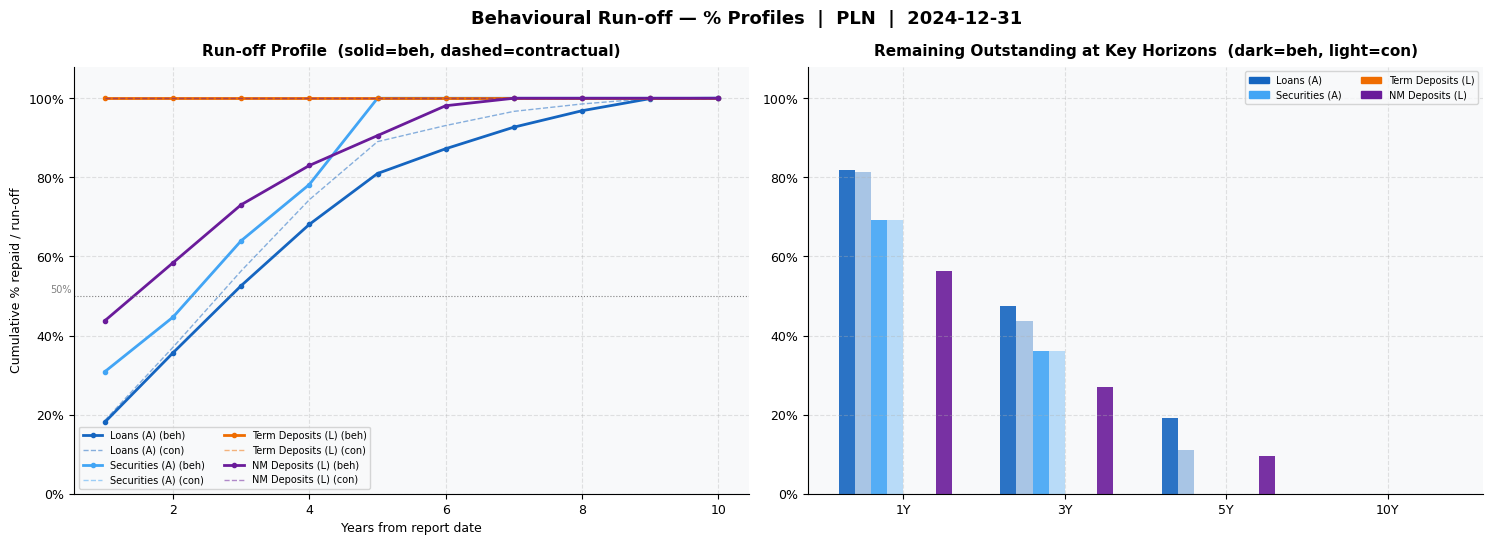

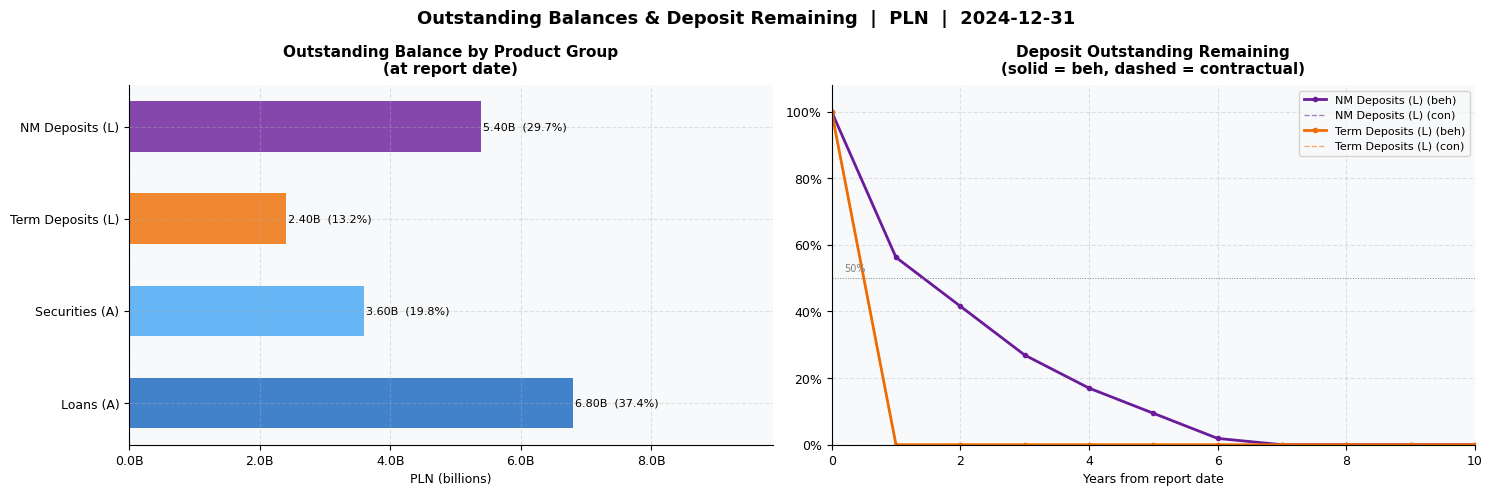


  OUTSTANDING BALANCES  |  PLN
  Subgroup                  Balance (M PLN) % of total
  ------------------------------------------------------
  Loans (A)                           6,800      37.4%
  Securities (A)                      3,600      19.8%
  Term Deposits (L)                   2,400      13.2%
  NM Deposits (L)                     5,400      29.7%
  TOTAL                              18,200     100.0%


In [12]:
# -------------------------------------------------------------------
# BEHAVIOURAL RUN-OFF -- % profiles + outstanding notional
# Split: NM deposits vs term deposits  |  loans vs securities
# -------------------------------------------------------------------
ro = runoff[runoff['currency'] == CCY].copy()
ro['yf'] = (ro['cf_end_dt'] - REPORT_DATE).dt.days / 365.25
ro['yr'] = np.ceil(ro['yf']).clip(1, 30).astype(int)


def _subgroup(row):
    pt = str(row.get('product_type', '')).upper()
    pn = str(row.get('product_name', '')).lower()
    if any(k in pn for k in ('current_account', 'saving', 'saving_account', 'demand')):
        return 'NM Deposits (L)'
    if pt == 'D' or 'deposit' in pn or 'account' in pn:
        return 'Term Deposits (L)'
    if pt == 'L' or any(k in pn for k in ('loan', 'mortgage', 'overdraft', 'leasing')):
        return 'Loans (A)'
    if pt == 'F' or any(k in pn for k in ('bond', 'security', 'tbill', 'treasury')):
        return 'Securities (A)'
    if pt == 'S' or 'swap' in pn:
        return 'Swaps'
    PTYPE = {'L': 'Loans (A)', 'D': 'Term Deposits (L)',
             'F': 'Securities (A)', 'S': 'Swaps'}
    return PTYPE.get(pt, 'Other')


ro['subgroup'] = ro.apply(_subgroup, axis=1)

# -- Outstanding balances by subgroup ----------------------------------------
def _sg_bs(row):
    pn = str(row.get('product_name', '')).lower()
    if any(k in pn for k in ('current_account', 'saving', 'saving_account', 'demand')):
        return 'NM Deposits (L)'
    if 'deposit' in pn or ('account' in pn and 'current' not in pn and 'saving' not in pn):
        return 'Term Deposits (L)'
    if any(k in pn for k in ('loan', 'mortgage', 'overdraft', 'leasing')):
        return 'Loans (A)'
    if any(k in pn for k in ('bond', 'security', 'tbill', 'treasury')):
        return 'Securities (A)'
    return 'Other'

if not outstanding_bal.empty:
    obs = outstanding_bal[outstanding_bal['currency'] == CCY].copy()
    obs['subgroup'] = obs.apply(_subgroup, axis=1)
    outstanding_by_sg = obs.groupby('subgroup')['balance_amt'].sum()
else:
    obs = bs_raw[bs_raw['currency'] == CCY].copy()
    obs['subgroup'] = obs.apply(_sg_bs, axis=1)
    outstanding_by_sg = obs.groupby('subgroup')['balance_amt'].sum()

# -- Build cumulative run-off -------------------------------------------------
cumul = (ro.groupby(['subgroup', 'yr'])[['beh_cap', 'con_cap']]
         .sum().reset_index().sort_values(['subgroup', 'yr']))
cumul['beh_cum'] = cumul.groupby('subgroup')['beh_cap'].cumsum()
cumul['con_cum'] = cumul.groupby('subgroup')['con_cap'].cumsum()
totals_b = cumul.groupby('subgroup')['beh_cap'].sum()
totals_c = cumul.groupby('subgroup')['con_cap'].sum()
for sg in cumul['subgroup'].unique():
    m  = cumul['subgroup'] == sg
    tb = max(totals_b.get(sg, 0), 1)
    tc = max(totals_c.get(sg, 0), 1)
    cumul.loc[m, 'beh_pct'] = cumul.loc[m, 'beh_cum'] / tb * 100
    cumul.loc[m, 'con_pct'] = cumul.loc[m, 'con_cum'] / tc * 100

# Distinct colors: assets=blue family, NM deposits=purple, term deposits=orange
SUBGROUP_COLOR = {
    'Loans (A)':        C_A,          # dark blue
    'Securities (A)':   '#42A5F5',    # light blue
    'NM Deposits (L)':  '#6A1B9A',    # purple
    'Term Deposits (L)':'#EF6C00',    # orange
    'Swaps':            C_GR,
    'Other':            '#90A4AE',
}
_SG_ORDER = ['Loans (A)', 'Securities (A)', 'Term Deposits (L)',
             'NM Deposits (L)', 'Swaps', 'Other']
all_sgs = sorted(cumul['subgroup'].unique(),
                 key=lambda s: _SG_ORDER.index(s) if s in _SG_ORDER else 99)

YR_MAX = int(min(cumul['yr'].max(), 15))
YRS    = list(range(1, YR_MAX + 1))

# -- Figure 1: % run-off profiles --------------------------------------------
fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5.5))
fig1.suptitle(f'Behavioural Run-off — % Profiles  |  {CCY}  |  {REPORT_DATE.date()}',
              fontsize=13, fontweight='bold')

for sg in all_sgs:
    grp   = cumul[cumul['subgroup'] == sg]
    color = SUBGROUP_COLOR.get(sg, C_GR)
    g2    = (grp[grp['yr'] <= YR_MAX].set_index('yr')
             .reindex(YRS).ffill().reset_index())
    ax1.plot(g2['yr'], g2['beh_pct'], color=color, lw=2,
             marker='o', ms=3, label=f'{sg} (beh)')
    ax1.plot(g2['yr'], g2['con_pct'], color=color, lw=1,
             linestyle='--', alpha=0.5, label=f'{sg} (con)')

ax1.axhline(50, color='grey', lw=0.8, linestyle=':')
ax1.text(YR_MAX * 0.02, 51, '50%', fontsize=7, color='grey')
ax1.set_xlabel('Years from report date')
ax1.set_ylabel('Cumulative % repaid / run-off')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
ax1.set_ylim(0, 108)
ax1.set_title('Run-off Profile  (solid=beh, dashed=contractual)')
ax1.legend(ncol=2, fontsize=7)

# Right: remaining outstanding % at key horizons (100% - cumulative run-off)
KEY_YRS = [y for y in [1, 3, 5, 10] if y <= YR_MAX]
x_k = np.arange(len(KEY_YRS))
bw  = 0.8 / max(len(all_sgs), 1)
for i, sg in enumerate(all_sgs):
    color = SUBGROUP_COLOR.get(sg, C_GR)
    grp   = cumul[cumul['subgroup'] == sg].set_index('yr')
    beh_rem = [100 - (grp.loc[grp.index[grp.index <= y].max(), 'beh_pct']
                     if any(grp.index <= y) else 0) for y in KEY_YRS]
    con_rem = [100 - (grp.loc[grp.index[grp.index <= y].max(), 'con_pct']
                     if any(grp.index <= y) else 0) for y in KEY_YRS]
    off = (i - len(all_sgs)/2 + 0.5) * bw
    ax2.bar(x_k + off - bw*0.25, beh_rem, bw*0.5, color=color, alpha=0.9)
    ax2.bar(x_k + off + bw*0.25, con_rem, bw*0.5, color=color, alpha=0.35)

ax2.set_xticks(x_k)
ax2.set_xticklabels([f'{y}Y' for y in KEY_YRS])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
ax2.set_ylim(0, 108)
ax2.set_title('Remaining Outstanding at Key Horizons  (dark=beh, light=con)')
_leg2 = [mpatches.Patch(color=SUBGROUP_COLOR.get(sg, C_GR), label=sg) for sg in all_sgs]
ax2.legend(handles=_leg2, fontsize=7, ncol=2)

plt.tight_layout()
plt.show()

# -- Figure 2: outstanding notional + deposit remaining balance --------------
obs_order = [sg for sg in all_sgs if sg in outstanding_by_sg.index and
             outstanding_by_sg.get(sg, 0) > 0]
if obs_order:
    fig2, (axO1, axO2) = plt.subplots(1, 2, figsize=(15, 5))
    fig2.suptitle(
        f'Outstanding Balances & Deposit Remaining  |  {CCY}  |  {REPORT_DATE.date()}',
        fontsize=13, fontweight='bold')

    # Left: outstanding notional horizontal bars
    obs_vals  = [outstanding_by_sg.get(sg, 0) for sg in obs_order]
    obs_clrs  = [SUBGROUP_COLOR.get(sg, C_GR)  for sg in obs_order]
    y_obs = np.arange(len(obs_order))
    axO1.barh(y_obs, [v/1e9 for v in obs_vals], color=obs_clrs, alpha=0.8, height=0.55)
    axO1.set_yticks(y_obs)
    axO1.set_yticklabels(obs_order, fontsize=9)
    axO1.xaxis.set_major_formatter(mticker.FuncFormatter(bn_fmt))
    axO1.set_xlabel('PLN (billions)')
    axO1.set_title('Outstanding Balance by Product Group\n(at report date)')
    tot_obs = sum(obs_vals)
    for i, v in enumerate(obs_vals):
        axO1.text(v/1e9 + 0.03, i,
                  f'{v/1e9:.2f}B  ({v/tot_obs*100:.1f}%)',
                  va='center', fontsize=8)
    axO1.set_xlim(0, max(v/1e9 for v in obs_vals) * 1.45)

    # Right: Deposit outstanding remaining over time (starts 100%, declines)
    dep_sgs = [sg for sg in ['NM Deposits (L)', 'Term Deposits (L)']
               if sg in cumul['subgroup'].unique()]
    if dep_sgs:
        for sg in dep_sgs:
            color = SUBGROUP_COLOR.get(sg, C_L)
            grp = (cumul[cumul['subgroup'] == sg]
                   .set_index('yr').reindex(YRS))
            beh_rem = 100 - grp['beh_pct'].ffill().fillna(0)
            con_rem = 100 - grp['con_pct'].ffill().fillna(0)
            yrs_ext = [0] + list(beh_rem.index)
            beh_ext = [100.0] + beh_rem.tolist()
            con_ext = [100.0] + con_rem.tolist()
            axO2.plot(yrs_ext, beh_ext, color=color, lw=2, marker='o', ms=3,
                      label=f'{sg} (beh)')
            axO2.plot(yrs_ext, con_ext, color=color, lw=1, linestyle='--',
                      alpha=0.55, label=f'{sg} (con)')
        axO2.axhline(50, color='grey', lw=0.7, linestyle=':')
        axO2.text(0.2, 52, '50%', fontsize=7, color='grey')
        axO2.set_xlim(0, YR_MAX)
        axO2.set_ylim(0, 108)
        axO2.set_xlabel('Years from report date')
        axO2.yaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
        axO2.set_title('Deposit Outstanding Remaining\n'
                       '(solid = beh, dashed = contractual)')
        axO2.legend(fontsize=8)
    else:
        axO2.text(0.5, 0.5, 'No deposit data', transform=axO2.transAxes,
                  ha='center', va='center', fontsize=11)

    plt.tight_layout()
    plt.show()

    # Summary table
    print(f'\n  OUTSTANDING BALANCES  |  {CCY}')
    print(f'  {"Subgroup":<24} {"Balance (M PLN)":>16} {"% of total":>10}')
    print(f'  {"-"*54}')
    for sg, v in zip(obs_order, obs_vals):
        print(f'  {sg:<24} {v/1e6:>16,.0f} {v/tot_obs*100:>9.1f}%')
    print(f'  {"TOTAL":<24} {tot_obs/1e6:>16,.0f} {"100.0%":>10}')


---
## 6. Simple NII Sensitivity  ±100 bps

**Gap-based approximation** using the repricing gap up to 12 months:  
$$\Delta NII = \sum_{\text{buckets} \leq 12M} \text{net\_gap} \times \Delta r \times \text{remain\_yf}$$

where `remain_yf = (12 - midpoint\_month) / 12` is the fraction of the year remaining after repricing.  
A **positive gap** (asset-sensitive) → positive ΔNII when rates rise.

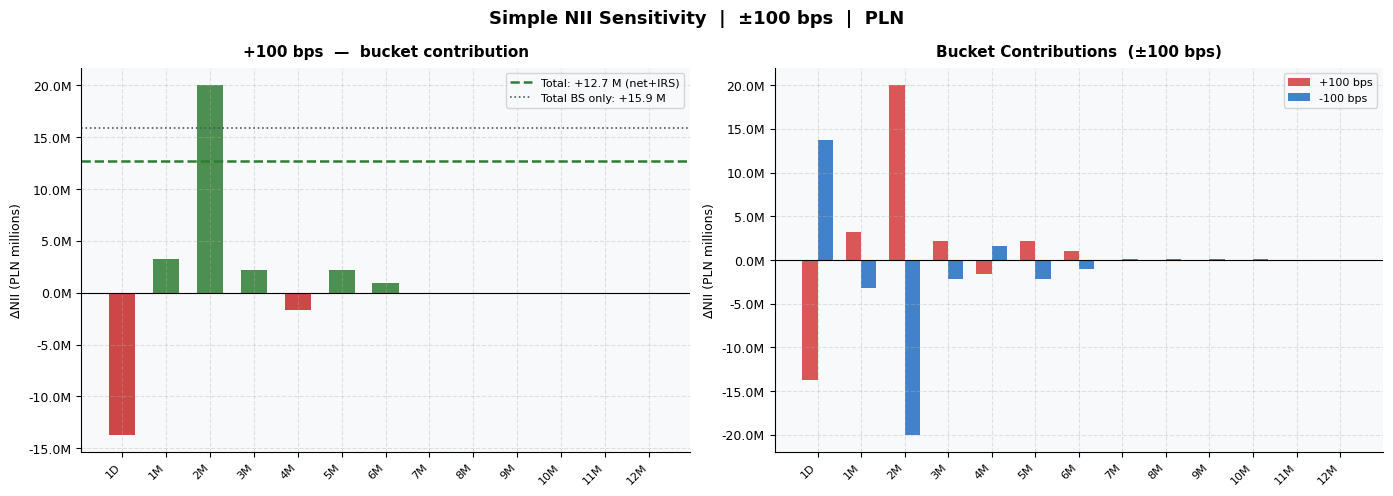


  Simple NII Sensitivity  |  PLN
  Scenario       BS only (M)   Net + IRS (M)
  ------------------------------------------
  + 100 bps            +15.9           +12.7
  - 100 bps            -15.9           -12.7

  Repricing gap ≤ 12M : +1,564 M PLN  (asset-sensitive)


In [13]:
g_nii = ir_gap[ir_gap['currency'] == CCY].copy()
net_nii = (g_nii.groupby('tenor_bucket')[['gap_cf', 'gap_cf_irs']]
           .sum().reset_index())
net_nii['net'] = net_nii['gap_cf'] + net_nii['gap_cf_irs']
net_nii = sbkt(net_nii)
net_nii['bkt_m'] = net_nii['tenor_bucket'].map(tkey)

nii12 = net_nii[net_nii['bkt_m'].between(0, 12)].copy()
# Midpoint in months: 1D -> 0, 1M -> 0.5, 2M -> 1.5, ..., 12M -> 11.5
nii12['mid_m'] = nii12['bkt_m'].apply(lambda m: 0.5 if m == 0 else m - 0.5)
nii12['remain_yf'] = ((12 - nii12['mid_m']) / 12).clip(0, 1)

SHOCK = 0.01  # 100 bps
nii12['dNII_up'] = nii12['net'] *  SHOCK * nii12['remain_yf']
nii12['dNII_dn'] = nii12['net'] * -SHOCK * nii12['remain_yf']
nii12['dNII_bs_up'] = nii12['gap_cf'] *  SHOCK * nii12['remain_yf']
nii12['dNII_bs_dn'] = nii12['gap_cf'] * -SHOCK * nii12['remain_yf']

tot_up = nii12['dNII_up'].sum()
tot_dn = nii12['dNII_dn'].sum()
tot_bs_up = nii12['dNII_bs_up'].sum()
tot_bs_dn = nii12['dNII_bs_dn'].sum()

labels_n = nii12['tenor_bucket'].tolist()
x_n = np.arange(len(labels_n))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'Simple NII Sensitivity  |  ±100 bps  |  {CCY}', fontsize=13, fontweight='bold')

# Left: +100 bps
col_up = [C_N if v >= 0 else C_L for v in nii12['dNII_up']]
ax1.bar(x_n, nii12['dNII_up']/1e6, color=col_up, alpha=0.85, width=0.6)
ax1.axhline(0, color='black', lw=0.8)
ax1.axhline(tot_up/1e6, color=C_N if tot_up >= 0 else C_L,
            lw=1.8, linestyle='--',
            label=f'Total: {tot_up/1e6:+.1f} M (net+IRS)')
ax1.axhline(tot_bs_up/1e6, color=C_GR, lw=1.2, linestyle=':',
            label=f'Total BS only: {tot_bs_up/1e6:+.1f} M')
ax1.set_xticks(x_n)
ax1.set_xticklabels(labels_n, rotation=45, ha='right', fontsize=8)
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}M'))
ax1.set_ylabel('ΔNII (PLN millions)')
ax1.set_title('+100 bps  —  bucket contribution')
ax1.legend()

# Right: both shocks side by side
w_r = 0.35
ax2.bar(x_n - w_r/2, nii12['dNII_up']/1e6, w_r, label='+100 bps', color=C_UP, alpha=0.8)
ax2.bar(x_n + w_r/2, nii12['dNII_dn']/1e6, w_r, label='-100 bps', color=C_DN, alpha=0.8)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_xticks(x_n)
ax2.set_xticklabels(labels_n, rotation=45, ha='right', fontsize=8)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:.1f}M'))
ax2.set_ylabel('ΔNII (PLN millions)')
ax2.set_title('Bucket Contributions  (±100 bps)')
ax2.legend()

plt.tight_layout()
plt.show()

print(f'\n  Simple NII Sensitivity  |  {CCY}')
print(f'  {"Scenario":<12} {"BS only (M)":>13} {"Net + IRS (M)":>15}')
print(f'  {"-"*42}')
print(f'  {"+ 100 bps":<12} {tot_bs_up/1e6:>+13.1f} {tot_up/1e6:>+15.1f}')
print(f'  {"- 100 bps":<12} {tot_bs_dn/1e6:>+13.1f} {tot_dn/1e6:>+15.1f}')

# Net gap 1Y summary
gap_1y = nii12['net'].sum()
print(f'\n  Repricing gap ≤ 12M : {gap_1y/1e6:+,.0f} M PLN  '
      f'({"asset-sensitive" if gap_1y >= 0 else "liability-sensitive"})')

### CF-Based NII by Scenario

Full CF-based NII from `irrbb.nii_results` split by **existing-book interest** and **renewal** income.

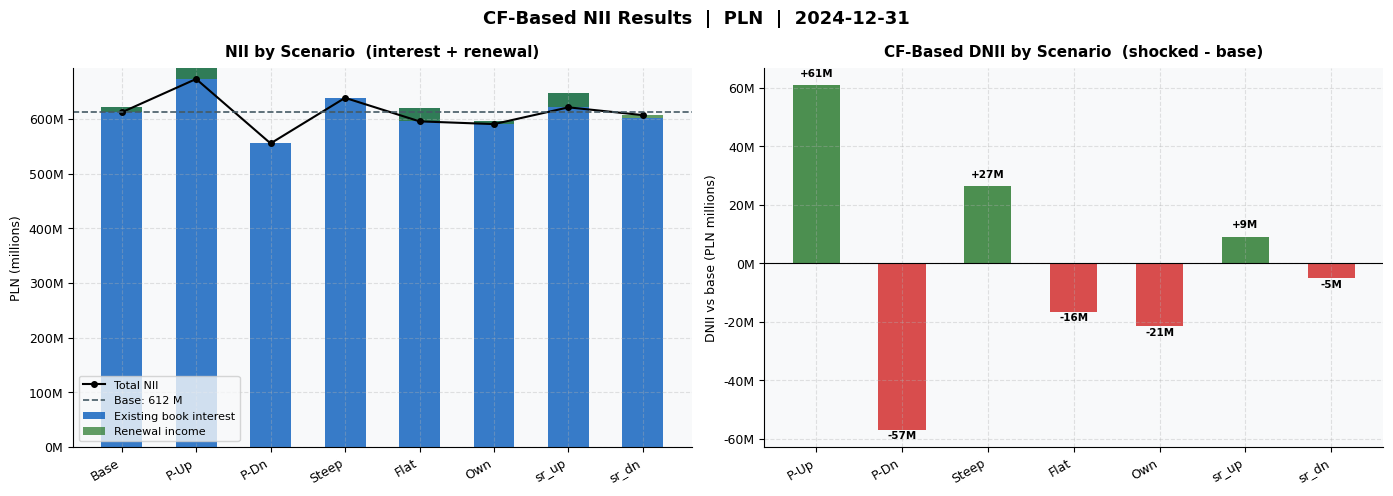

In [14]:
# ── NII base: interest vs renewal + delta by scenario ───────────────────────
nii_b = nii_scen[nii_scen['currency'] == CCY].copy()
_sid_order = ['base', 'par_up', 'par_dn', 'steep', 'flat', 'short_up', 'short_dn', 'own']
nii_b = (nii_b.assign(
            order=lambda d: d['scenario_id'].map({s: i for i, s in enumerate(_sid_order)}))
          .sort_values('order').reset_index(drop=True))
_lbl_map = {'base': 'Base', 'par_up': 'P-Up', 'par_dn': 'P-Dn',
            'steep': 'Steep', 'flat': 'Flat',
            'short_up': 'S-Up', 'short_dn': 'S-Dn', 'own': 'Own'}
nii_b['label'] = nii_b['scenario_id'].map(_lbl_map).fillna(nii_b['scenario_id'])

base_nii_val = float(nii_b.loc[nii_b['scenario_id'] == 'base', 'nii_total'].iloc[0]) \
               if 'base' in nii_b['scenario_id'].values else 0.0

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle(f'CF-Based NII Results  |  {CCY}  |  {REPORT_DATE.date()}',
             fontsize=13, fontweight='bold')

# Left: stacked bars
x2 = np.arange(len(nii_b))
ax1.bar(x2, nii_b['nii_interest'] / 1e6, 0.55,
        label='Existing book interest', color=C_A, alpha=0.85)
ax1.bar(x2, nii_b['nii_renewal']  / 1e6, 0.55,
        bottom=nii_b['nii_interest'] / 1e6,
        label='Renewal income', color=C_N, alpha=0.75)
ax1.plot(x2, nii_b['nii_total'] / 1e6, color='black', marker='o', ms=4, lw=1.5,
         label='Total NII')
ax1.axhline(base_nii_val / 1e6, color=C_GR, lw=1.2, linestyle='--',
            label=f'Base: {base_nii_val/1e6:,.0f} M')
ax1.set_xticks(x2)
ax1.set_xticklabels(nii_b['label'].tolist(), rotation=30, ha='right')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
ax1.set_ylabel('PLN (millions)')
ax1.set_title('NII by Scenario  (interest + renewal)')
ax1.legend()

# Right: DNII vs base
shocked_nb = nii_b[nii_b['scenario_id'] != 'base'].copy()
if not shocked_nb.empty:
    shocked_nb['delta_nii'] = shocked_nb['nii_total'] - base_nii_val
    x_s = np.arange(len(shocked_nb))
    cols_d = [C_UP if v < 0 else C_N for v in shocked_nb['delta_nii']]
    ax2.bar(x_s, shocked_nb['delta_nii'] / 1e6, color=cols_d, alpha=0.85, width=0.55)
    ax2.axhline(0, color='black', lw=0.8)
    for i, v in enumerate(shocked_nb['delta_nii']):
        offset = 3 if v >= 0 else -3
        ax2.text(i, v / 1e6 + offset, f'{v/1e6:+.0f}M',
                 ha='center', fontsize=7.5, fontweight='bold')
    ax2.set_xticks(x_s)
    ax2.set_xticklabels(shocked_nb['label'].tolist(), rotation=30, ha='right')
    ax2.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
    ax2.set_ylabel('DNII vs base (PLN millions)')
    ax2.set_title('CF-Based DNII by Scenario  (shocked - base)')
else:
    ax2.text(0.5, 0.5, 'No shocked NII data', transform=ax2.transAxes,
             ha='center', va='center')
plt.tight_layout()
plt.show()


---
## 7. EBA IRRBB Supervisory Outlier Test (SOT)

**EVE SOT** — threshold: ΔEVE / Tier 1 < **−15 %** (regulatory haircut applied: positive Δ discounted at 50%).  
**NII SOT** — threshold: ΔNII / Tier 1 < **−5 %** (same 50% haircut on positive Δ).  
Results sourced from `irrbb.irrbb_report` (written by `eba_sot_workflow`).

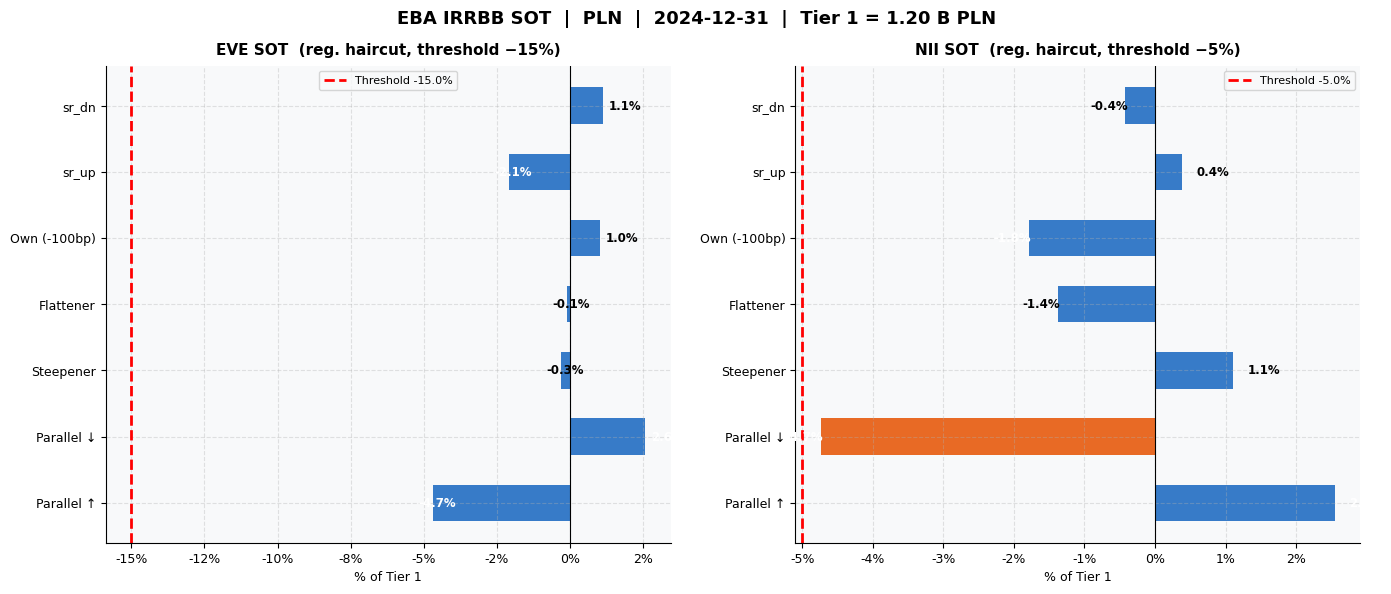


  Scenario        ΔEVE (M)    EVE%  EVE_reg%    ΔNII (M)    NII%  NII_reg%  Breach
  ------------------------------------------------------------------------------
  Parallel ↑           -56    -4.7%      -4.7%         +61     5.1%       2.5%  
  Parallel ↓           +61     5.1%       2.6%         -57    -4.7%      -4.7%  
  Steepener             -4    -0.3%      -0.3%         +27     2.2%       1.1%  
  Flattener             -1    -0.1%      -0.1%         -16    -1.4%      -1.4%  
  Own (-100bp)         +25     2.1%       1.0%         -21    -1.8%      -1.8%  
  sr_up                -25    -2.1%      -2.1%          +9     0.8%       0.4%  
  sr_dn                +27     2.2%       1.1%          -5    -0.4%      -0.4%  
  ------------------------------------------------------------------------------
  Tier 1 capital: 1.200 B PLN


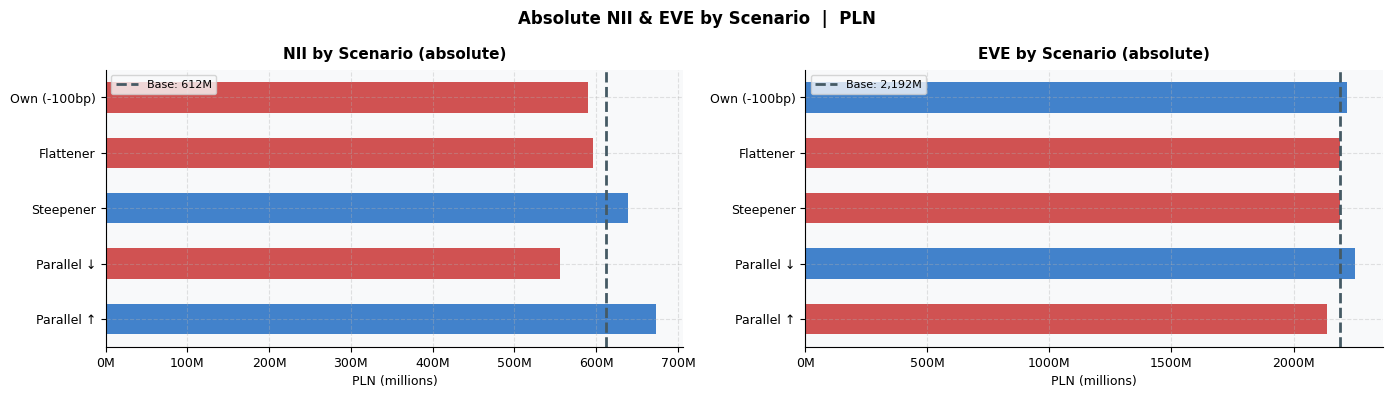

In [15]:
SID_ORDER = ['par_up', 'par_dn', 'steep', 'flat', 'short_up', 'short_dn', 'own']
SID_LABEL = {
    'par_up':   'Parallel ↑',
    'par_dn':   'Parallel ↓',
    'steep':    'Steepener',
    'flat':     'Flattener',
    'short_up': 'Short ↑',
    'short_dn': 'Short ↓',
    'own':      'Own (-100bp)',
}

if irrbb_sot.empty:
    print('No SOT data — run eba_sot_workflow first.')
else:
    sot = (irrbb_sot[irrbb_sot['currency'] == CCY].copy()
           .assign(order=lambda d: d['scenario_id'].map({s: i for i, s in enumerate(SID_ORDER)}))
           .sort_values('order').reset_index(drop=True))
    sot['label'] = sot['scenario_id'].map(SID_LABEL).fillna(sot['scenario_id'])

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle(f'EBA IRRBB SOT  |  {CCY}  |  {REPORT_DATE.date()}'
                 f'  |  Tier 1 = {tier1/1e9:.2f} B PLN',
                 fontsize=13, fontweight='bold')

    def sot_bar(ax, df, col_pct, threshold, title):
        vals   = df[col_pct].fillna(0).tolist()
        labels = df['label'].tolist()
        y_pos  = np.arange(len(labels))
        colors = []
        for v in vals:
            if v < threshold:        colors.append(C_L)
            elif v < threshold * 0.7: colors.append(C_WN)
            else:                     colors.append(C_A)
        bars = ax.barh(y_pos, vals, color=colors, alpha=0.85, height=0.55)
        ax.axvline(threshold, color='red', lw=2, linestyle='--',
                   label=f'Threshold {threshold}%')
        ax.axvline(0, color='black', lw=0.8)
        for i, v in enumerate(vals):
            x_txt = v - 0.5 if v < 0 else v + 0.2
            ax.text(x_txt, i, f'{v:.1f}%', va='center', fontsize=8.5,
                    color='white' if abs(v) > 1.5 else 'black', fontweight='bold')
        ax.set_yticks(y_pos)
        ax.set_yticklabels(labels, fontsize=9)
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
        ax.set_xlabel('% of Tier 1')
        ax.set_title(title)
        ax.legend()
        breach_n = sum(1 for v in vals if v < threshold)
        if breach_n:
            ax.text(0.98, 0.02, f'{breach_n} BREACH(ES)',
                    transform=ax.transAxes, ha='right', va='bottom',
                    color=C_L, fontweight='bold', fontsize=10)

    sot_bar(ax1, sot, 'sot_eve_pct_reg', -15.0, 'EVE SOT  (reg. haircut, threshold −15%)')
    sot_bar(ax2, sot, 'sot_nii_pct_reg', -5.0,  'NII SOT  (reg. haircut, threshold −5%)')

    plt.tight_layout()
    plt.show()

    # ── Numeric table ──────────────────────────────────────────────────────────
    print(f'\n  {"Scenario":<13} {"ΔEVE (M)":>10} {"EVE%":>7} {"EVE_reg%":>9}'
          f'  {"ΔNII (M)":>10} {"NII%":>7} {"NII_reg%":>9}  Breach')
    print(f'  {"-"*78}')
    for _, r in sot.iterrows():
        eve_b = '*** EVE' if r.get('sot_eve_pct_reg', 0) < -15 else ''
        nii_b = '/ NII'   if r.get('sot_nii_pct_reg', 0) < -5  else ''
        breach = (eve_b + ' ' + nii_b).strip()
        print(f'  {r["label"]:<13} '
              f'{r.get("delta_eve",0)/1e6:>+10,.0f} '
              f'{r.get("sot_eve_pct",0):>7.1f}% '
              f'{r.get("sot_eve_pct_reg",0):>9.1f}%  '
              f'{r.get("delta_nii",0)/1e6:>+10,.0f} '
              f'{r.get("sot_nii_pct",0):>7.1f}% '
              f'{r.get("sot_nii_pct_reg",0):>9.1f}%  {breach}')
    print(f'  {"-"*78}')
    print(f'  Tier 1 capital: {tier1/1e9:.3f} B PLN')

    # ── NII & EVE absolute by scenario ────────────────────────────────────────
    fig2, (ax3, ax4) = plt.subplots(1, 2, figsize=(14, 4))
    fig2.suptitle(f'Absolute NII & EVE by Scenario  |  {CCY}', fontsize=12, fontweight='bold')

    def abs_bar(ax, df_scen, col, title, base_sid='base'):
        d = df_scen[df_scen['currency'] == CCY].copy()
        base_val = float(d.loc[d['scenario_id'] == base_sid, col].sum() if base_sid in d['scenario_id'].values else 0)
        d = (d[d['scenario_id'].isin(SID_ORDER)]
             .assign(order=lambda x: x['scenario_id'].map({s: i for i, s in enumerate(SID_ORDER)}))
             .sort_values('order'))
        if d.empty: return
        vals_abs = d[col].tolist()
        y_pos = np.arange(len(vals_abs))
        colors = [C_A if v >= base_val else C_L for v in vals_abs]
        ax.barh(y_pos, [v/1e6 for v in vals_abs], color=colors, alpha=0.8, height=0.55)
        ax.axvline(base_val/1e6, color=C_GR, lw=2, linestyle='--',
                   label=f'Base: {base_val/1e6:,.0f}M')
        ax.set_yticks(y_pos)
        ax.set_yticklabels([SID_LABEL.get(s, s) for s in d['scenario_id']])
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
        ax.set_xlabel('PLN (millions)')
        ax.set_title(title)
        ax.legend()

    abs_bar(ax3, nii_scen, 'nii_total', 'NII by Scenario (absolute)')
    abs_bar(ax4, eve_scen, 'pv_total',  'EVE by Scenario (absolute)')
    plt.tight_layout()
    plt.show()

---
## 10. Non-linearity Analysis (NII & EVE)

Interest-rate sensitivity **is not linear**: a shock twice as large does not produce exactly twice the P&L impact due to convexity, floors/caps, and optionality.

This section tests linearity by comparing:
- **Linear proxy**: ±1 bps sensitivity × 100 or × 250
- **Exact result**: full revaluation under ±100 bps and ±250 bps (EBA parallel)

The scatter plots show ΔEVE and ΔNII against shock size; the dashed line is the ±1 bps linear extrapolation. Deviation from this line reveals convexity.



  Non-linearity Table  |  PLN  |  2024-12-31
  Base NII: +612.1 M PLN    Base EVE: +2,192.2 M PLN

  Metric  Shock    Linear (M)    Exact (M)   Diff (M)    Diff%
  ------------------------------------------------------------
  EVE       +1          +0.5         +0.5       +0.0    +0.0%
  EVE       -1          +1.0         +1.0       +0.0    +0.0%
  NII       +1          +0.4         +0.4       +0.0    +0.0%
  NII       -1          -0.1         -0.1       +0.0    +0.0%
  EVE     +100         +54.5        -22.6      -77.0  -341.5%
  EVE     -100        +101.7        +24.7      -77.0  -311.4%
  EVE     +250        +136.2        -56.5     -192.6  -341.2%
  EVE     -250        +254.3        +61.4     -192.9  -314.2%
  NII     +100         +37.9        +29.8       -8.1   -27.2%
  NII     -100         -14.8        -22.9       -8.1   -35.3%
  NII     +250         +94.7        +61.1      -33.7   -55.1%
  NII     -250         -37.1        -56.8      -19.8   -34.8%


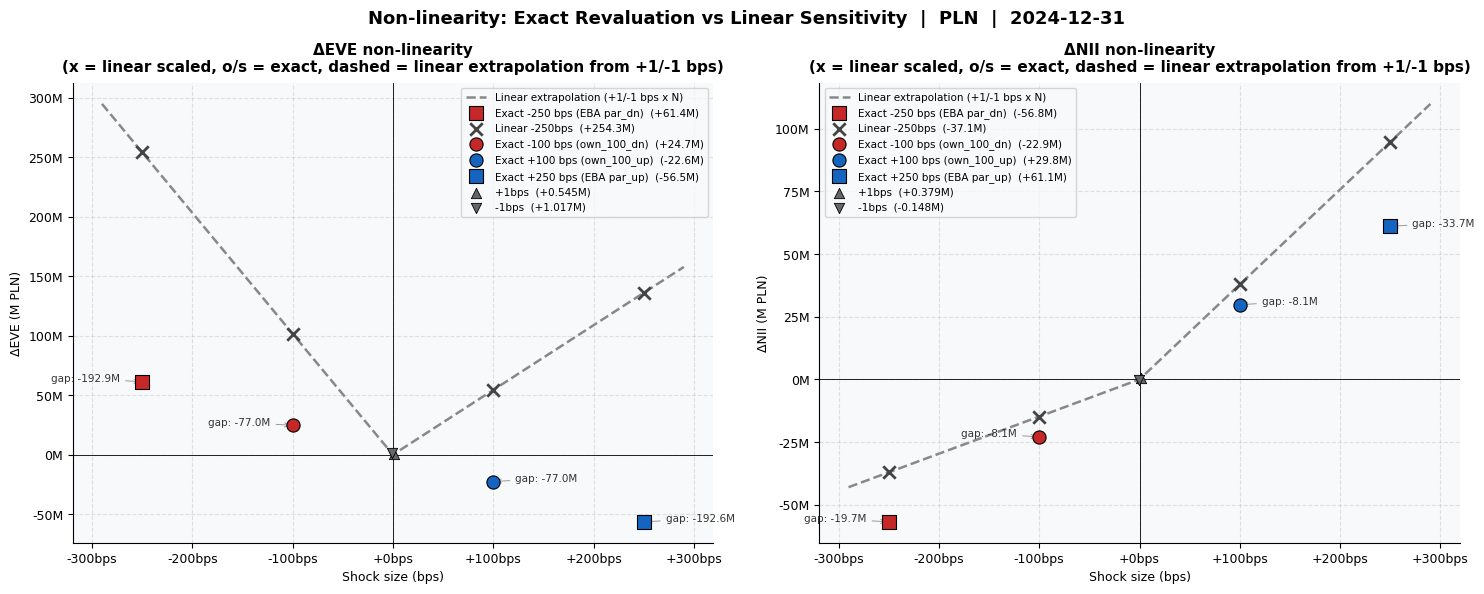

In [16]:
# ─────────────────────────────────────────────────────────────────────────────
# NON-LINEARITY ANALYSIS  — ±1 bps × 100/250  vs exact ±100 / ±250 bps
# ─────────────────────────────────────────────────────────────────────────────
_ccy = CCY

def _get(df, sid, col):
    if df.empty: return 0.0
    sub = df[(df['scenario_id'] == sid) & (df['currency'] == _ccy)]
    return float(sub[col].sum()) if not sub.empty else 0.0

# Base
_nii_base = _get(nii_scen, 'base', 'nii_total')
_eve_base  = _get(eve_scen, 'base', 'pv_total')
# CF-table base: same pipeline as nii_own -> use for 1bps delta
_nii_cf_base = _get(nii_cf_base, 'base', 'nii_total') if not nii_cf_base.empty else _nii_base

# ±1 bps absolute NII / EVE from own scenarios
_nii_1up = _get(nii_own, 'own_1_up', 'nii_total')
_nii_1dn = _get(nii_own, 'own_1_dn', 'nii_total')
_eve_1up = _get(eve_own, 'own_1_up', 'pv_total')
_eve_1dn = _get(eve_own, 'own_1_dn', 'pv_total')

# ±1 bps deltas — use CF-table base for NII (consistent pipeline)
_dnii_1up = _nii_1up - _nii_cf_base
_dnii_1dn = _nii_1dn - _nii_cf_base
_deve_1up = _eve_1up - _eve_base
_deve_1dn = _eve_1dn - _eve_base

# ±100 bps exact (own scenarios)
_nii_100up = _get(nii_own, 'own_100_up', 'nii_total') - _nii_base
_nii_100dn = _get(nii_own, 'own_100_dn', 'nii_total') - _nii_base
_eve_100up = _get(eve_own, 'own_100_up', 'pv_total')  - _eve_base
_eve_100dn = _get(eve_own, 'own_100_dn', 'pv_total')  - _eve_base

# ±250 bps exact (EBA par_up / par_dn — PLN shock = 250 bps)
_nii_250up = _get(nii_scen, 'par_up', 'nii_total') - _nii_base
_nii_250dn = _get(nii_scen, 'par_dn', 'nii_total') - _nii_base
_eve_250up = _get(eve_scen, 'par_up', 'pv_total')  - _eve_base
_eve_250dn = _get(eve_scen, 'par_dn', 'pv_total')  - _eve_base

# ─── Non-linearity summary table ─────────────────────────────────────────────────────────────
_rows = []
# +1 bps and -1 bps explicit rows
for metric, d1up, d1dn in [
    ('EVE', _deve_1up, _deve_1dn),
    ('NII', _dnii_1up, _dnii_1dn),
]:
    for bps, exact in [(+1, d1up), (-1, d1dn)]:
        _rows.append({
            'Metric':           metric,
            'Shock (bps)':      f'{bps:+d}',
            'Linear 1bp*N (M)': round(exact / 1e6, 3),
            'Exact (M)':        round(exact / 1e6, 3),
            'Diff (M)':         0.0,
            'Diff (%)':         0.0,
        })
for metric, d1up, d1dn, ex100up, ex100dn, ex250up, ex250dn in [
    ('EVE', _deve_1up, _deve_1dn, _eve_100up, _eve_100dn, _eve_250up, _eve_250dn),
    ('NII', _dnii_1up, _dnii_1dn, _nii_100up, _nii_100dn, _nii_250up, _nii_250dn),
]:
    for bps, lin1, exact in [
        (+100, d1up, ex100up), (-100, d1dn, ex100dn),
        (+250, d1up, ex250up), (-250, d1dn, ex250dn),
    ]:
        lin_scaled = lin1 * abs(bps)  # lin1 is signed delta; abs(bps) scales magnitude
        diff       = exact - lin_scaled
        diff_pct   = diff / abs(exact) * 100 if exact else float('nan')
        _rows.append({
            'Metric':           metric,
            'Shock (bps)':      f'{bps:+d}',
            'Linear 1bp*N (M)': round(lin_scaled / 1e6, 2),
            'Exact (M)':        round(exact       / 1e6, 2),
            'Diff (M)':         round(diff        / 1e6, 2),
            'Diff (%)':         round(diff_pct,    2),
        })

_tbl = pd.DataFrame(_rows)
print(f'\n  Non-linearity Table  |  {CCY}  |  {REPORT_DATE.date()}')
print(f'  Base NII: {_nii_base/1e6:+,.1f} M PLN    Base EVE: {_eve_base/1e6:+,.1f} M PLN')
print()
print(f'  {"Metric":<5} {"Shock":>6}  {"Linear (M)":>12} {"Exact (M)":>12} {"Diff (M)":>10} {"Diff%":>8}')
print(f'  {"-"*60}')
for _, r in _tbl.iterrows():
    pc = r['Diff (%)']
    pc_s = f'{pc:+.1f}%' if not pd.isna(pc) else 'n/a'
    print(f'  {r["Metric"]:<5} {r["Shock (bps)"]:>6}  '
          f'{r["Linear 1bp*N (M)"]:>+12.1f} {r["Exact (M)"]:>+12.1f} '
          f'{r["Diff (M)"]:>+10.1f} {pc_s:>8}')

# ─── Scatter plots: EVE and NII non-linearity ─────────────────────────────────────────────────
_pts = {
    'EVE': {-250: _eve_250dn, -100: _eve_100dn, -1: _deve_1dn,
            +1: _deve_1up, +100: _eve_100up, +250: _eve_250up},
    'NII': {-250: _nii_250dn, -100: _nii_100dn, -1: _dnii_1dn,
            +1: _dnii_1up, +100: _nii_100up, +250: _nii_250up},
}
_EXACT_MARKERS = {
    -250: ('s', C_L,  'Exact -250 bps (EBA par_dn)'),
    -100: ('o', C_L,  'Exact -100 bps (own_100_dn)'),
    +100: ('o', C_A,  'Exact +100 bps (own_100_up)'),
    +250: ('s', C_A,  'Exact +250 bps (EBA par_up)'),
}

fig3, (ax_e, ax_n) = plt.subplots(1, 2, figsize=(15, 6))
fig3.suptitle(
    f'Non-linearity: Exact Revaluation vs Linear Sensitivity  |  {CCY}  |  {REPORT_DATE.date()}',
    fontsize=13, fontweight='bold')

for ax, metric, ylabel in [(ax_e, 'EVE', 'ΔEVE (M PLN)'), (ax_n, 'NII', 'ΔNII (M PLN)')]:
    pts = _pts[metric]
    _bps_x = np.linspace(-290, 290, 500)

    # Linear reference: piecewise through ±1 bps points
    _slope_up = pts.get(+1, 0.0)
    _slope_dn = pts.get(-1, 0.0)
    _lin_y = np.where(_bps_x >= 0,
                      _bps_x * _slope_up / 1e6,
                      _bps_x * (-_slope_dn) / 1e6)
    ax.plot(_bps_x, _lin_y, color='#888888', lw=1.8, ls='--',
            label='Linear extrapolation (+1/-1 bps x N)', zorder=1)
    ax.axhline(0, color='black', lw=0.6)
    ax.axvline(0, color='black', lw=0.6)

    # Plot exact points
    for bps in [-250, -100, +100, +250]:
        mk, col_m, lbl_m = _EXACT_MARKERS[bps]
        val = pts.get(bps, 0.0)
        ax.scatter(bps, val / 1e6, marker=mk, color=col_m, s=90, zorder=4,
                   edgecolors='black', linewidths=0.8,
                   label=f'{lbl_m}  ({val/1e6:+.1f}M)')

        # Corresponding linear approximation (cross marker)
        lin_val = (pts.get(+1, 0.0) * bps if bps > 0
                   else pts.get(-1, 0.0) * abs(bps))
        _lin_lbl = f'Linear {bps:+d}bps  ({lin_val/1e6:+.1f}M)' if bps == -250 else '_'
        ax.scatter(bps, lin_val / 1e6, marker='x', color='#444444', s=80,
                   linewidths=2.0, zorder=3, label=_lin_lbl)

        # Annotation: convexity gap (exact - linear)
        gap = val - lin_val
        if abs(gap) > 0.1e6:
            x_off = 22 if bps > 0 else -22
            ax.annotate(f'gap: {gap/1e6:+.1f}M',
                        xy=(bps, val / 1e6),
                        xytext=(bps + x_off, val / 1e6),
                        fontsize=7.5, color='#333333',
                        ha='left' if bps > 0 else 'right',
                        arrowprops=dict(arrowstyle='->', color='#999999', lw=0.7))

    # ±1 bps points (small markers)
    for b1 in [+1, -1]:
        v1 = pts.get(b1, 0.0)
        ax.scatter(b1, v1 / 1e6, marker='^' if b1 > 0 else 'v',
                   color='#666666', s=55, zorder=3, edgecolors='black', lw=0.6,
                   label=('+1bps' if b1 > 0 else '-1bps') + f'  ({v1/1e6:+.3f}M)')

    _metric_lbl = 'ΔEVE' if metric == 'EVE' else 'ΔNII'
    _title_line2 = '(x = linear scaled, o/s = exact, dashed = linear extrapolation from +1/-1 bps)'
    ax.set_title(f'{_metric_lbl} non-linearity\n' + _title_line2)
    ax.set_xlabel('Shock size (bps)')
    ax.set_ylabel(ylabel)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:+.0f}bps'))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
    ax.legend(fontsize=7.5)

plt.tight_layout()
plt.show()


---
## 8. LCR & NSFR

- **LCR** = HQLA / Net outflows over 30 days — minimum **100 %**.  
- **NSFR** = Available Stable Funding (ASF) / Required Stable Funding (RSF) — minimum **100 %**.

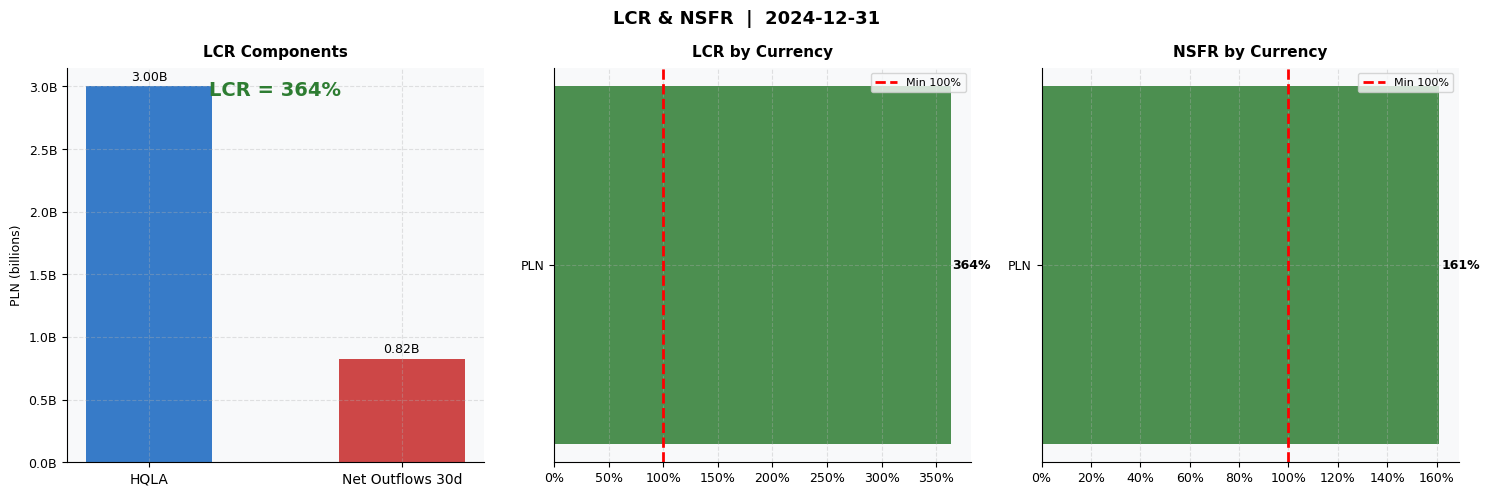


  Currency   HQLA (B)  Out 30d (B)   LCR (%)    ASF (B)   RSF (B)  NSFR (%)
  ------------------------------------------------------------------------
  PLN            3.00         0.82    364.0%       8.56      5.32    160.9%


In [17]:
if lcr_nsfr.empty:
    print('LCR/NSFR data not available. Run lcr_nsfr_workflow first.')
else:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    fig.suptitle(f'LCR & NSFR  |  {REPORT_DATE.date()}', fontsize=13, fontweight='bold')

    # ── LCR component waterfall ────────────────────────────────────────────────
    ax = axes[0]
    tot = lcr_nsfr.sum(numeric_only=True)
    hqla_v = tot.get('hqla', 0)
    out_v  = tot.get('net_outflows_30d', 0)
    lcr_r  = hqla_v / out_v if out_v > 0 else 0
    lcr_col = C_OK if lcr_r >= 1 else C_L
    ax.bar([0, 1], [hqla_v/1e9, out_v/1e9],
           color=[C_A, C_L], alpha=0.85, width=0.5)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['HQLA', 'Net Outflows 30d'], fontsize=10)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(bn_fmt))
    ax.set_ylabel('PLN (billions)')
    ax.set_title('LCR Components')
    ax.text(0.5, 0.93, f'LCR = {lcr_r*100:.0f}%',
            transform=ax.transAxes, ha='center', fontsize=14,
            fontweight='bold', color=lcr_col)
    for i, v in enumerate([hqla_v/1e9, out_v/1e9]):
        ax.text(i, v + 0.05, f'{v:.2f}B', ha='center', fontsize=9)

    # ── LCR by currency ────────────────────────────────────────────────────────
    ax2 = axes[1]
    lc2 = lcr_nsfr.sort_values('currency')
    if 'lcr' in lc2.columns:
        lcr_pct = lc2['lcr'] * 100
        bar_c = [C_OK if v >= 100 else C_L for v in lcr_pct]
        y2 = np.arange(len(lc2))
        ax2.barh(y2, lcr_pct, color=bar_c, alpha=0.85, height=0.5)
        ax2.axvline(100, color='red', lw=2, linestyle='--', label='Min 100%')
        ax2.set_yticks(y2)
        ax2.set_yticklabels(lc2['currency'].tolist())
        ax2.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
        ax2.set_title('LCR by Currency')
        ax2.legend()
        for i, v in enumerate(lcr_pct):
            ax2.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9, fontweight='bold')

    # ── NSFR by currency ──────────────────────────────────────────────────────
    ax3 = axes[2]
    lc3 = lcr_nsfr.sort_values('currency')
    if 'asf' in lc3.columns and 'rsf' in lc3.columns:
        nsfr_pct = (lc3['asf'] / lc3['rsf'].replace(0, np.nan) * 100).fillna(0)
        bar_c3 = [C_OK if v >= 100 else C_L for v in nsfr_pct]
        y3 = np.arange(len(lc3))
        ax3.barh(y3, nsfr_pct, color=bar_c3, alpha=0.85, height=0.5)
        ax3.axvline(100, color='red', lw=2, linestyle='--', label='Min 100%')
        ax3.set_yticks(y3)
        ax3.set_yticklabels(lc3['currency'].tolist())
        ax3.xaxis.set_major_formatter(mticker.FuncFormatter(pct_fmt))
        ax3.set_title('NSFR by Currency')
        ax3.legend()
        for i, v in enumerate(nsfr_pct):
            ax3.text(v + 1, i, f'{v:.0f}%', va='center', fontsize=9, fontweight='bold')

    plt.tight_layout()
    plt.show()

    # ── Summary table ──────────────────────────────────────────────────────────
    print(f'\n  {"Currency":<8} {"HQLA (B)":>10} {"Out 30d (B)":>12} {"LCR (%)":>9}'
          f'  {"ASF (B)":>9} {"RSF (B)":>9} {"NSFR (%)":>9}')
    print(f'  {"-"*72}')
    for _, r in lcr_nsfr.iterrows():
        lcr_p  = r.get('lcr', 0) * 100
        nsfr_p = (r.get('asf', 0) / r.get('rsf', 1)) * 100 if r.get('rsf', 0) > 0 else 0
        lcr_flag  = ' !' if lcr_p  < 100 else ''
        nsfr_flag = ' !' if nsfr_p < 100 else ''
        print(f'  {str(r.get("currency","")):<8} '
              f'{r.get("hqla",0)/1e9:>10.2f} '
              f'{r.get("net_outflows_30d",0)/1e9:>12.2f} '
              f'{lcr_p:>8.1f}%{lcr_flag}'
              f'  {r.get("asf",0)/1e9:>9.2f} '
              f'{r.get("rsf",0)/1e9:>9.2f} '
              f'{nsfr_p:>8.1f}%{nsfr_flag}')

---
## 9. Additional ALM Insights

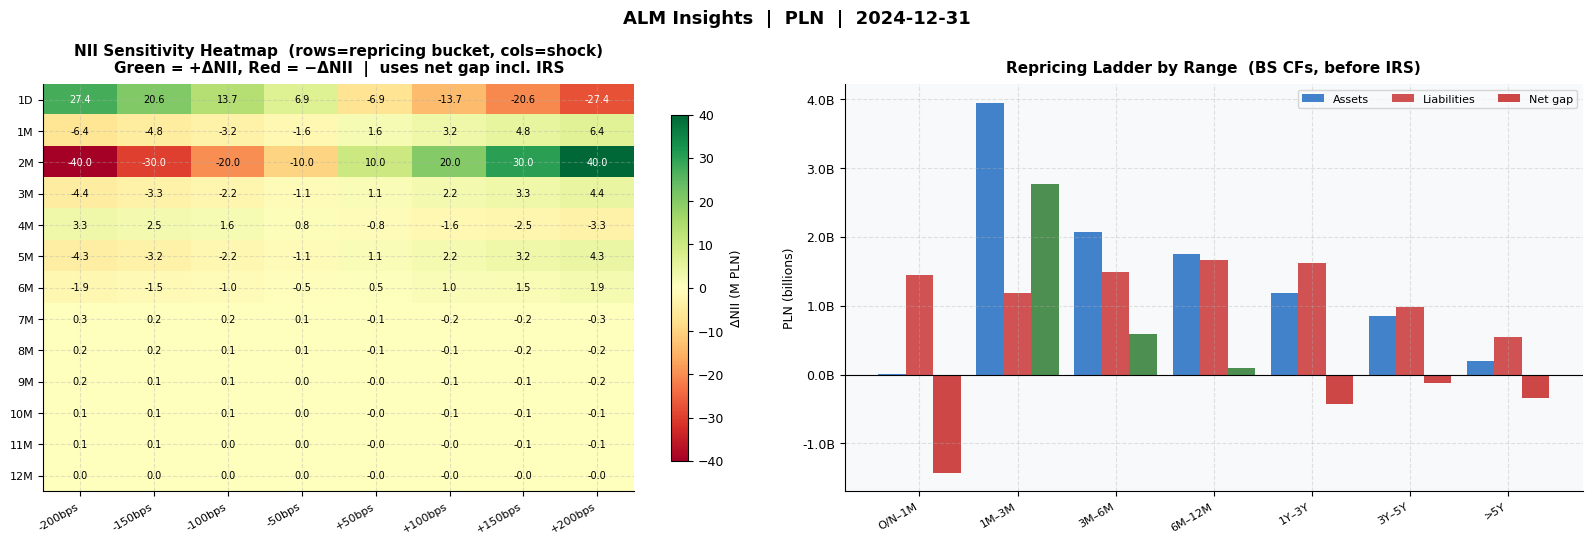

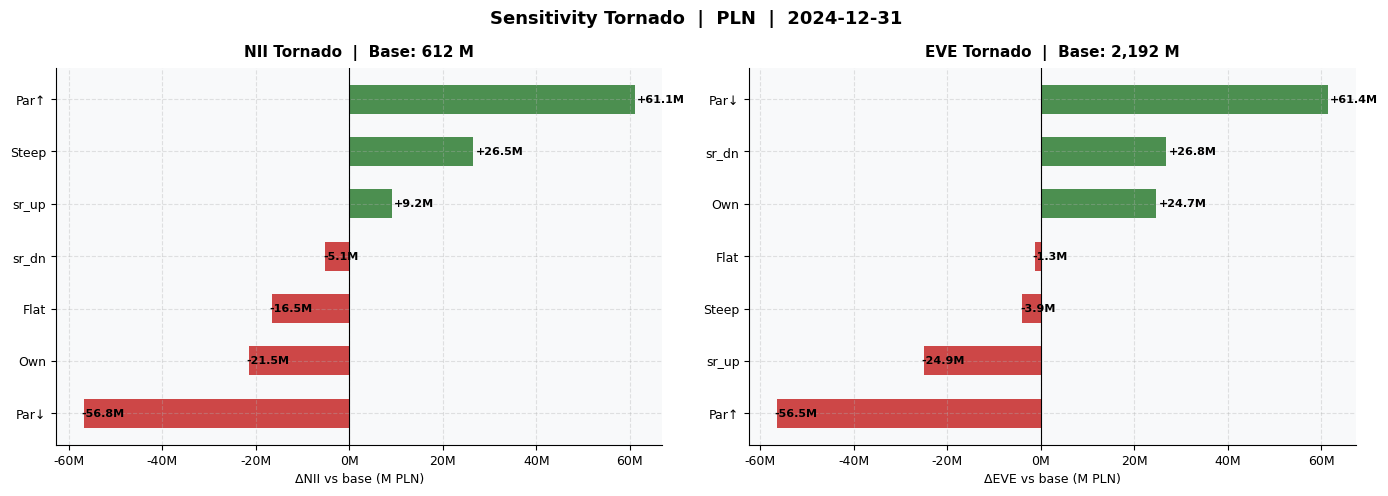

In [18]:
# ─────────────────────────────────────────────────────────────────────────────
# ADDITIONAL ALM VISUALIZATIONS
# (A) NII rate sensitivity heatmap  — bucket × shock
# (B) Repricing ladder by range     — asset vs liability stacked
# (C) NII & EVE tornado charts
# ─────────────────────────────────────────────────────────────────────────────
import matplotlib.colors as mcolors

# ── A. Rate sensitivity heatmap ───────────────────────────────────────────────
g_heat = ir_gap[ir_gap['currency'] == CCY].copy()
net_heat = g_heat.groupby('tenor_bucket')[['gap_cf', 'gap_cf_irs']].sum().reset_index()
net_heat['net'] = net_heat['gap_cf'] + net_heat['gap_cf_irs']
net_heat = sbkt(net_heat)
net_heat['bkt_m'] = net_heat['tenor_bucket'].map(tkey)
net_12 = net_heat[net_heat['bkt_m'].between(0, 12)].copy()
net_12['mid_m']     = net_12['bkt_m'].apply(lambda m: 0.5 if m == 0 else m - 0.5)
net_12['remain_yf'] = ((12 - net_12['mid_m']) / 12).clip(0, 1)

SHOCKS_BPS = [-200, -150, -100, -50, +50, +100, +150, +200]
heat_data  = {}
for bps in SHOCKS_BPS:
    s = bps / 10_000
    heat_data[f'{bps:+d}bps'] = (
        net_12['net'] * s * net_12['remain_yf'] / 1e6).values
heat_df = pd.DataFrame(heat_data, index=net_12['tenor_bucket'].tolist())

fig_h, axes_h = plt.subplots(1, 2, figsize=(16, 5.5))
fig_h.suptitle(f'ALM Insights  |  {CCY}  |  {REPORT_DATE.date()}',
               fontsize=13, fontweight='bold')

axH = axes_h[0]
vabs = max(abs(heat_df.values.max()), abs(heat_df.values.min()), 0.1)
norm = mcolors.TwoSlopeNorm(vmin=-vabs, vcenter=0, vmax=vabs)
im   = axH.imshow(heat_df.values, aspect='auto', cmap=plt.cm.RdYlGn, norm=norm)
axH.set_xticks(range(len(heat_df.columns)))
axH.set_xticklabels(heat_df.columns, rotation=30, ha='right', fontsize=8)
axH.set_yticks(range(len(heat_df.index)))
axH.set_yticklabels(heat_df.index, fontsize=8)
plt.colorbar(im, ax=axH, label='ΔNII (M PLN)', shrink=0.85)
for i in range(len(heat_df.index)):
    for j in range(len(heat_df.columns)):
        v = heat_df.iloc[i, j]
        axH.text(j, i, f'{v:.1f}', ha='center', va='center',
                 fontsize=7, color='black' if abs(v) < vabs * 0.55 else 'white')
axH.set_title('NII Sensitivity Heatmap  (rows=repricing bucket, cols=shock)\n'
              'Green = +ΔNII, Red = −ΔNII  |  uses net gap incl. IRS')

# ── B. Repricing ladder by broad range ────────────────────────────────────────
RANGES = [
    ('O/N–1M',    0,   1),
    ('1M–3M',     1,   3),
    ('3M–6M',     3,   6),
    ('6M–12M',    6,  12),
    ('1Y–3Y',    12,  36),
    ('3Y–5Y',    36,  60),
    ('>5Y',       60, 9999),
]
g_lr = ir_gap[ir_gap['currency'] == CCY].copy()
g_lr['bkt_m'] = g_lr['tenor_bucket'].map(tkey)
a_grp = g_lr[g_lr['bs_side'] == 'A'].groupby('bkt_m')['gap_cf'].sum()
l_grp = g_lr[g_lr['bs_side'] == 'L'].groupby('bkt_m')['gap_cf'].sum()

rl, ra, rl2, rn = [], [], [], []
for lbl, lo, hi in RANGES:
    mask = lambda idx, lo=lo, hi=hi: [(lo <= m < hi) for m in idx]
    va = a_grp[mask(a_grp.index)].sum() / 1e9
    vl = l_grp[mask(l_grp.index)].sum() / 1e9
    rl.append(lbl); ra.append(va); rl2.append(abs(vl)); rn.append(va - abs(vl))

axD = axes_h[1]
x_d = np.arange(len(rl))
w_d = 0.28
axD.bar(x_d - w_d, ra,  w_d, label='Assets',       color=C_A, alpha=0.80)
axD.bar(x_d,       rl2, w_d, label='Liabilities',  color=C_L, alpha=0.80)
net_cols = [C_N if v >= 0 else C_L for v in rn]
axD.bar(x_d + w_d, rn,  w_d, label='Net gap',
        color=net_cols, alpha=0.85)
axD.axhline(0, color='black', lw=0.8)
axD.set_xticks(x_d)
axD.set_xticklabels(rl, rotation=30, ha='right', fontsize=8)
axD.yaxis.set_major_formatter(mticker.FuncFormatter(bn_fmt))
axD.set_ylabel('PLN (billions)')
axD.set_title('Repricing Ladder by Range  (BS CFs, before IRS)')
axD.legend(ncol=3, fontsize=8)

plt.tight_layout()
plt.show()

# ── C. NII & EVE tornado charts ────────────────────────────────────────────────
_SID_LBL = {'par_up':'Par↑','par_dn':'Par↓','steep':'Steep','flat':'Flat',
             'short_up':'Short↑','short_dn':'Short↓','own':'Own'}

nii_t = nii_scen[(nii_scen['currency'] == CCY) &
                  (nii_scen['scenario_id'] != 'base')].copy()
eve_t = eve_scen[(eve_scen['currency'] == CCY) &
                  (eve_scen['scenario_id'] != 'base')].copy()

has_nii = not nii_t.empty
has_eve = not eve_t.empty

if has_nii or has_eve:
    fig_t, axes_t = plt.subplots(1, 2, figsize=(14, 5))
    fig_t.suptitle(f'Sensitivity Tornado  |  {CCY}  |  {REPORT_DATE.date()}',
                   fontsize=13, fontweight='bold')

    base_nii_t = float(
        nii_scen[(nii_scen['currency'] == CCY) &
                 (nii_scen['scenario_id'] == 'base')]['nii_total'].sum()
    ) if 'base' in nii_scen['scenario_id'].values else 0.0
    base_eve_t = float(
        eve_scen[(eve_scen['currency'] == CCY) &
                 (eve_scen['scenario_id'] == 'base')]['pv_total'].sum()
    ) if 'base' in eve_scen['scenario_id'].values else 0.0

    def _tornado(ax, df, col, base_val, xlabel, title):
        df = df.copy()
        df['delta'] = df[col] - base_val
        df['label'] = df['scenario_id'].map(_SID_LBL).fillna(df['scenario_id'])
        df = df.sort_values('delta')
        y = np.arange(len(df))
        cols = [C_OK if v >= 0 else C_L for v in df['delta']]
        ax.barh(y, df['delta'] / 1e6, color=cols, alpha=0.85, height=0.55)
        ax.axvline(0, color='black', lw=0.8)
        for i, v in enumerate(df['delta']):
            offset = 0.5 if v >= 0 else -0.5
            ax.text(v/1e6 + offset, i, f'{v/1e6:+.1f}M',
                    va='center', fontsize=8, fontweight='bold')
        ax.set_yticks(y)
        ax.set_yticklabels(df['label'].tolist())
        ax.xaxis.set_major_formatter(mticker.FuncFormatter(mn_fmt))
        ax.set_xlabel(xlabel)
        ax.set_title(title)

    if has_nii:
        _tornado(axes_t[0], nii_t, 'nii_total', base_nii_t,
                 'ΔNII vs base (M PLN)', f'NII Tornado  |  Base: {base_nii_t/1e6:,.0f} M')
    else:
        axes_t[0].text(0.5, 0.5, 'No NII data', transform=axes_t[0].transAxes,
                       ha='center', va='center')

    if has_eve:
        _tornado(axes_t[1], eve_t, 'pv_total', base_eve_t,
                 'ΔEVE vs base (M PLN)', f'EVE Tornado  |  Base: {base_eve_t/1e6:,.0f} M')
    else:
        axes_t[1].text(0.5, 0.5, 'No EVE data', transform=axes_t[1].transAxes,
                       ha='center', va='center')

    plt.tight_layout()
    plt.show()
else:
    print('No NII/EVE scenario data available for tornado chart.')
